In [ ]:
import sys
import torch

print("Python:", sys.executable)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

DATA_ROOT = Path(
    r"C:\GymProject\data\Dataset Exercise Quality-wise"
)

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"راجع مسار البيانات: {DATA_ROOT}")

exercises = ["squat", "push_up", "bicep_curl"]
qualities = ["good", "bad"]

fig, axes = plt.subplots(6, 3, figsize=(15, 20))
row = 0

for exercise in exercises:
    for quality in qualities:
        folder = DATA_ROOT / exercise / quality / "side"
        videos = sorted(folder.glob("*.mp4"))

        if not videos:
            raise FileNotFoundError(f"لا توجد فيديوهات في: {folder}")

        video = videos[0]
        cap = cv2.VideoCapture(str(video))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"{exercise}/{quality}: {video.name}")

        for col, fraction in enumerate([0.2, 0.5, 0.8]):
            ax = axes[row, col]
            ax.axis("off")

            frame_index = int(max(total_frames - 1, 0) * fraction)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
            ok, frame = cap.read()

            if ok:
                ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            else:
                ax.text(0.5, 0.5, "Cannot read frame",
                        ha="center", va="center")

            ax.set_title(
                f"{exercise} / {quality} / {int(fraction * 100)}%"
            )

        cap.release()
        row += 1

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import re
import random
import pandas as pd

DATA_ROOT = Path(
    r"C:\GymProject\data\Dataset Exercise Quality-wise"
)
EXERCISES = {"squat", "push_up", "bicep_curl"}

rows = []

for video in sorted(DATA_ROOT.rglob("*.mp4")):
    parts = video.relative_to(DATA_ROOT).parts
    if len(parts) != 4:
        continue

    exercise, quality, view, filename = parts
    if exercise not in EXERCISES:
        continue

    match = re.search(r"subject_(\d+)", filename)
    if not match:
        raise ValueError(f"لم أستطع تحديد الشخص: {filename}")

    rows.append({
        "path": str(video),
        "subject": match.group(1),
        "exercise": exercise,
        "quality": quality,
        "view": view,
    })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("لم نجد فيديوهات التمارين المطلوبة؛ راجع المسار.")

subjects = sorted(df["subject"].unique())
random.Random(42).shuffle(subjects)

if len(subjects) < 12:
    raise ValueError("عدد الأشخاص أقل من المتوقع؛ راجع البيانات.")

groups = {
    "test": subjects[:4],
    "val": subjects[4:8],
    "train": subjects[8:],
}

subject_split = {
    subject: split
    for split, members in groups.items()
    for subject in members
}
df["split"] = df["subject"].map(subject_split)

assert df.groupby("subject")["split"].nunique().max() == 1

for split in ["train", "val", "test"]:
    print(f"{split}: {len(groups[split])} subjects — {groups[split]}")

print("\nعدد الفيديوهات لكل فئة:")
display(
    pd.crosstab(
        [df["exercise"], df["quality"]],
        df["split"]
    ).reindex(columns=["train", "val", "test"], fill_value=0)
)

print("\nإجمالي الفيديوهات:", len(df))

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

pose_model = YOLO("yolo11s-pose.pt")

# عينات من التدريب فقط، من التصوير الجانبي
samples = (
    df[
        (df["split"] == "train") &
        (df["view"] == "side")
    ]
    .sort_values(["exercise", "quality", "subject"])
    .groupby(["exercise", "quality"], sort=True)
    .head(1)
)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for ax, (_, sample) in zip(axes.flat, samples.iterrows()):
    ax.axis("off")
    ax.set_title(
        f"{sample['exercise']} / {sample['quality']}"
        f" / subject {sample['subject']}"
    )

    cap = cv2.VideoCapture(sample["path"])
    try:
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, total // 2))
        ok, frame = cap.read()
    finally:
        cap.release()

    if not ok:
        ax.text(0.5, 0.5, "Cannot read frame", ha="center")
        print("تعذرت قراءة:", sample["path"])
        continue

    result = pose_model.predict(
        source=frame,
        device=0,
        imgsz=960,
        conf=0.20,
        verbose=False
    )[0]

    annotated = result.plot()
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

    print(
        f"{sample['exercise']} / {sample['quality']}: "
        f"{len(result.boxes)} person(s) detected"
    )

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# مسار الفيديو المطلوب فحصه
video_path = Path(
    r"C:\GymProject\data\Dataset Exercise Quality-wise"
    r"\squat\bad\side\subject_001_squat_bad_side.mp4"
)

if not video_path.is_file():
    raise FileNotFoundError(f"الفيديو غير موجود:\n{video_path}")

# يستخدم كرت الشاشة إذا كان متاحًا
device = 0 if torch.cuda.is_available() else "cpu"

# يستخدم الوزن الموجود؛ ينزله فقط إذا لم يجده
pose_model = YOLO("yolo11s-pose.pt")

cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    cap.release()
    raise RuntimeError("تعذر فتح الفيديو")

fig, axes = plt.subplots(2, 4, figsize=(16, 10))

try:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        raise RuntimeError("تعذر معرفة عدد إطارات الفيديو")

    positions = np.linspace(0.10, 0.90, 8)

    for ax, fraction in zip(axes.flat, positions):
        ax.axis("off")

        frame_number = int((total_frames - 1) * fraction)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        ok, frame = cap.read()

        if not ok:
            ax.set_title(f"Video {fraction:.0%}")
            ax.text(
                0.5, 0.5,
                "Cannot read frame",
                ha="center",
                va="center"
            )
            continue

        result = pose_model.predict(
            source=frame,
            device=device,
            imgsz=960,
            conf=0.20,
            verbose=False
        )[0]

        count = len(result.boxes)

        if count > 0:
            # حساب مساحة كل صندوق واختيار الأكبر
            boxes = result.boxes.xyxy
            areas = (
                (boxes[:, 2] - boxes[:, 0]) *
                (boxes[:, 3] - boxes[:, 1])
            )

            selected_index = int(areas.argmax().item())

            # الاحتفاظ بصندوق ومفاصل الشخص المختار فقط
            selected = result[
                selected_index:selected_index + 1
            ]

            annotated = selected.plot()
            confidence = float(selected.boxes.conf[0].item())

            ax.set_title(
                f"Video {fraction:.0%}\n"
                f"Detection confidence: {confidence:.2f}"
            )

            print(
                f"{fraction:.0%}: detected {count} person(s), "
                f"selected largest box"
            )
        else:
            annotated = frame.copy()
            ax.set_title(
                f"Video {fraction:.0%}\nNo person detected"
            )
            print(f"{fraction:.0%}: no person detected")

        ax.imshow(
            cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        )

finally:
    cap.release()

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

samples = (
    df[
        (df["split"] == "train") &
        (df["view"] == "side")
    ]
    .sort_values(["exercise", "quality", "subject"])
    .groupby(["exercise", "quality"], sort=True)
    .head(1)
)

fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for row, (_, sample) in enumerate(samples.iterrows()):
    cap = cv2.VideoCapture(sample["path"])

    try:
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        for col, fraction in enumerate([0.2, 0.5, 0.8]):
            ax = axes[row, col]
            ax.axis("off")
            ax.set_title(
                f"{sample['exercise']} / {sample['quality']}"
                f" / {fraction:.0%}"
            )

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(max(total - 1, 0) * fraction)
            )
            ok, frame = cap.read()

            if not ok:
                ax.text(0.5, 0.5, "Cannot read frame", ha="center")
                continue

            result = pose_model.predict(
                source=frame,
                device=0,
                imgsz=960,
                conf=0.20,
                verbose=False
            )[0]

            if len(result.boxes):
                boxes = result.boxes.xyxy
                areas = (
                    (boxes[:, 2] - boxes[:, 0]) *
                    (boxes[:, 3] - boxes[:, 1])
                )

                index = int(areas.argmax().item())
                selected = result[index:index + 1]
                annotated = selected.plot()
            else:
                annotated = frame
                ax.set_title(
                    f"{sample['exercise']} / {sample['quality']}"
                    f" / {fraction:.0%}\nNo detection"
                )

            ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

    finally:
        cap.release()

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

OUTPUT = Path(r"C:\GymProject\prepared\exercise_type_v1")

# يمنع خلط نتائج تشغيل سابق ببيانات جديدة
if OUTPUT.exists():
    raise FileExistsError(
        f"المجلد موجود بالفعل: {OUTPUT}\n"
        "لا تعِد التشغيل قبل مراجعة محتوياته."
    )

required = {"path", "subject", "exercise", "quality", "view", "split"}
assert required.issubset(df.columns), "شغّل خلية تقسيم البيانات أولًا"
assert df.groupby("subject")["split"].nunique().max() == 1

OUTPUT.mkdir(parents=True)
df.to_csv(OUTPUT / "video_manifest.csv", index=False)

def fit_image(frame, size=320):
    """تصغير مع الحفاظ على النسب وإضافة حواف."""
    height, width = frame.shape[:2]
    scale = size / max(height, width)

    new_width = max(1, round(width * scale))
    new_height = max(1, round(height * scale))

    resized = cv2.resize(frame, (new_width, new_height))
    canvas = np.full((size, size, 3), 114, dtype=np.uint8)

    x = (size - new_width) // 2
    y = (size - new_height) // 2
    canvas[y:y + new_height, x:x + new_width] = resized
    return canvas

records = []
failures = []

for number, (_, row) in enumerate(df.iterrows(), start=1):
    video = Path(row["path"])
    destination = OUTPUT / row["split"] / row["exercise"]
    destination.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video))

    try:
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if not cap.isOpened() or total <= 0:
            failures.append({"video": str(video), "reason": "open_failed"})
            continue

        indices = np.unique(
            np.linspace(
                int((total - 1) * 0.10),
                int((total - 1) * 0.90),
                12
            ).astype(int)
        )

        for frame_index in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
            ok, frame = cap.read()

            if not ok:
                failures.append({
                    "video": str(video),
                    "reason": f"read_failed_{frame_index}"
                })
                continue

            image_path = destination / (
                f"{video.stem}_frame_{frame_index:06d}.jpg"
            )

            if not cv2.imwrite(str(image_path), fit_image(frame)):
                raise IOError(f"تعذر حفظ الصورة: {image_path}")

            records.append({
                "image": str(image_path),
                "video": str(video),
                "subject": row["subject"],
                "exercise": row["exercise"],
                "split": row["split"],
                "frame": int(frame_index)
            })

    finally:
        cap.release()

    if number % 25 == 0:
        print(f"Processed {number}/{len(df)} videos")

images = pd.DataFrame(records)
images.to_csv(OUTPUT / "image_manifest.csv", index=False)
pd.DataFrame(
    failures, columns=["video", "reason"]
).to_csv(OUTPUT / "read_failures.csv", index=False)

print("\nالصور المحفوظة:", len(images))
print("أخطاء القراءة:", len(failures))

if not images.empty:
    display(pd.crosstab(images["exercise"], images["split"]))

print("المجلد:", OUTPUT)

In [ ]:
from pathlib import Path
from datetime import datetime
import torch
from ultralytics import YOLO

DATA = Path(r"C:\GymProject\prepared\exercise_type_v1")
CLASSES = {"squat", "push_up", "bicep_curl"}

assert torch.cuda.is_available(), "اختر Kernel: Gym YOLO GPU"

# التأكد من وجود صور الفئات في كل مجموعة
for split in ["train", "val", "test"]:
    folder = DATA / split
    assert folder.is_dir(), f"المجلد مفقود: {folder}"

    found = {p.name for p in folder.iterdir() if p.is_dir()}
    assert found == CLASSES, f"فئات غير متوقعة في {split}: {found}"

    counts = {
        name: len(list((folder / name).glob("*.jpg")))
        for name in sorted(CLASSES)
    }
    assert all(counts.values()), f"فئة فارغة في {split}"
    print(split, counts)

print("GPU:", torch.cuda.get_device_name(0))

# تنزيل وزن البداية مرة واحدة، ثم تدريبه على بياناتنا
model = YOLO("yolo11n-cls.pt")

run_name = "exercise_type_" + datetime.now().strftime("%Y%m%d_%H%M%S")

results = model.train(
    data=str(DATA),
    epochs=30,
    patience=8,
    imgsz=320,
    batch=16,
    device=0,
    workers=0,          # مناسب للتشغيل داخل Jupyter على Windows
    project=r"C:\GymProject\runs",
    name=run_name,
    seed=42,
    val=True,
    save=True,
    plots=True,
    cache=False,
    amp=False,
    scale=0.0,          # تقليل قص أجزاء الجسم أثناء التدريب
    fliplr=0.5,
    flipud=0.0,
    auto_augment=None,
    erasing=0.0
)

run_dir = Path(model.trainer.save_dir)
print("\nمجلد النتائج:", run_dir)
print("أفضل وزن:", run_dir / "weights" / "best.pt")

In [ ]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image

RUN = Path(r"C:\GymProject\runs\exercise_type_20260921_132115")
DATA = Path(r"C:\GymProject\prepared\exercise_type_v1")
WEIGHTS = RUN / "weights" / "best.pt"

assert WEIGHTS.is_file(), f"الوزن غير موجود: {WEIGHTS}"

best_model = YOLO(str(WEIGHTS))

test_metrics = best_model.val(
    data=str(DATA),
    split="test",
    imgsz=320,
    batch=16,
    device=0,
    workers=0,
    plots=True,
    project=str(RUN),
    name="test_evaluation"
)

print(f"\nTest Top-1 Accuracy: {test_metrics.top1:.2%}")

output = Path(test_metrics.save_dir)
print("نتائج الاختبار:", output)

matrix = output / "confusion_matrix.png"
if matrix.is_file():
    display(Image(filename=str(matrix)))

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from IPython.display import display

# المسارات
DATA = Path(r"C:\GymProject\prepared\exercise_type_v1")
RUN = Path(r"C:\GymProject\runs\exercise_type_20260921_132115")
WEIGHTS = RUN / "weights" / "best.pt"
OUTPUT = RUN / "video_evaluation"
OUTPUT.mkdir(parents=True, exist_ok=True)

assert WEIGHTS.is_file(), f"ملف النموذج غير موجود: {WEIGHTS}"

manifest_path = DATA / "image_manifest.csv"
assert manifest_path.is_file(), f"ملف الصور غير موجود: {manifest_path}"

manifest = pd.read_csv(manifest_path, dtype={"subject": str})

required = {"image", "video", "exercise", "split"}
assert required.issubset(manifest.columns), (
    f"أعمدة ناقصة: {required - set(manifest.columns)}"
)

test_images = manifest.loc[manifest["split"] == "test"].copy()
assert not test_images.empty, "لا توجد صور اختبار في الملف."

# التحقق من وجود الصور قبل بدء التقييم
missing = [
    str(p) for p in test_images["image"]
    if not Path(p).is_file()
]
assert not missing, f"صور غير موجودة، مثال: {missing[:3]}"

# تحميل النموذج الذي درّبناه
model = YOLO(str(WEIGHTS))
class_names = [model.names[i] for i in range(len(model.names))]

assert set(test_images["exercise"]).issubset(set(class_names))

groups = list(test_images.groupby("video", sort=True))
print("الفئات:", class_names)
print("عدد فيديوهات الاختبار:", len(groups))
print("عدد صور الاختبار:", len(test_images))

video_rows = []
frame_rows = []

for number, (video_path, group) in enumerate(groups, start=1):
    assert group["exercise"].nunique() == 1, (
        f"أكثر من تمرين مسجل للفيديو: {video_path}"
    )
    assert len(group) == 12, (
        f"الفيديو {video_path} يحتوي {len(group)} صورة بدل 12."
    )

    paths = group["image"].astype(str).tolist()
    true_label = group["exercise"].iloc[0]

    results = model.predict(
        source=paths,
        imgsz=320,
        device=0,
        verbose=False,
        save=False,
    )
    assert len(results) == len(paths)

    # صف لكل صورة، وعمود لكل تمرين
    probabilities = np.stack([
        result.probs.data.cpu().numpy()
        for result in results
    ])

    assert np.isfinite(probabilities).all()

    # قرار واحد للفيديو بمتوسط احتمالات صوره
    mean_probabilities = probabilities.mean(axis=0)
    predicted_id = int(mean_probabilities.argmax())
    predicted_label = class_names[predicted_id]

    row = {
        "video": str(video_path),
        "true": true_label,
        "predicted": predicted_label,
        "correct": predicted_label == true_label,
        "frames": len(paths),
        "mean_score": float(mean_probabilities[predicted_id]),
    }

    for class_id, class_name in enumerate(class_names):
        row[f"prob_{class_name}"] = float(
            mean_probabilities[class_id]
        )

    video_rows.append(row)

    for path, probs in zip(paths, probabilities):
        frame_row = {
            "image": path,
            "video": str(video_path),
            "true": true_label,
            "predicted": class_names[int(probs.argmax())],
        }
        for class_id, class_name in enumerate(class_names):
            frame_row[f"prob_{class_name}"] = float(probs[class_id])
        frame_rows.append(frame_row)

    if number % 12 == 0 or number == len(groups):
        print(f"Processed {number}/{len(groups)} videos")

video_results = pd.DataFrame(video_rows)
frame_results = pd.DataFrame(frame_rows)

# حساب النتائج
accuracy = accuracy_score(
    video_results["true"], video_results["predicted"]
)
correct = int(video_results["correct"].sum())

print(f"\nVideo-level Test Accuracy: {accuracy:.2%}")
print(f"Correct videos: {correct}/{len(video_results)}")

report = classification_report(
    video_results["true"],
    video_results["predicted"],
    labels=class_names,
    digits=4,
    zero_division=0,
)
print("\n", report)

# حفظ النتائج
video_results.to_csv(
    OUTPUT / "video_predictions.csv",
    index=False, encoding="utf-8-sig"
)
frame_results.to_csv(
    OUTPUT / "frame_predictions.csv",
    index=False, encoding="utf-8-sig"
)
(OUTPUT / "classification_report.txt").write_text(
    f"Video accuracy: {accuracy:.4%}\n"
    f"Correct: {correct}/{len(video_results)}\n\n{report}",
    encoding="utf-8",
)

# المصفوفة: الصفوف للحقيقة، والأعمدة للتوقع
matrix = confusion_matrix(
    video_results["true"],
    video_results["predicted"],
    labels=class_names,
)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names,
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title(f"Video-level Test Accuracy: {accuracy:.2%}")
plt.tight_layout()
fig.savefig(
    OUTPUT / "video_confusion_matrix.png",
    dpi=180, bbox_inches="tight"
)
plt.show()

# عرض الفيديوهات التي أخطأ النموذج فيها
errors = video_results.loc[~video_results["correct"]].copy()
errors["filename"] = errors["video"].map(lambda p: Path(p).name)

if errors.empty:
    print("لا توجد أخطاء في فيديوهات هذه العينة.")
else:
    print("\nالفيديوهات المصنفة خطأ:")
    display(errors[["filename", "true", "predicted", "mean_score"]])

print("\nتم حفظ النتائج في:", OUTPUT)

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display

PROJECT = Path(r"C:\GymProject")
DATA = PROJECT / "prepared" / "exercise_type_v1"
OUTPUT = PROJECT / "outputs" / "squat_angles_val"
OUTPUT.mkdir(parents=True, exist_ok=True)

# استخدام الوزن الموجود محليًا، دون تنزيل جديد
candidates = [
    PROJECT / "yolo11s-pose.pt",
    Path.cwd() / "yolo11s-pose.pt",
]
POSE_WEIGHT = next((p for p in candidates if p.is_file()), None)

assert POSE_WEIGHT is not None, (
    "لم أجد yolo11s-pose.pt. ضع الملف الموجود عندك داخل C:\\GymProject"
)

videos = pd.read_csv(
    DATA / "video_manifest.csv",
    dtype={"subject": str}
)

selected = videos.loc[
    (videos["split"] == "val")
    & (videos["exercise"] == "squat")
    & (videos["view"] == "side")
].sort_values(["subject", "quality"])

assert len(selected) == 8, (
    f"المتوقع 8 فيديوهات، لكن الموجود {len(selected)}"
)
assert all(Path(p).is_file() for p in selected["path"]), (
    "بعض مسارات الفيديوهات غير موجودة."
)

pose = YOLO(str(POSE_WEIGHT))

# إعدادات أولية لفحص الإشارر
TARGET_FPS = 10
KEYPOINT_CONF = 0.50

# فهارس: الورك، الركبة، الكاحل
SIDES = {
    "left": [11, 13, 15],
    "right": [12, 14, 16],
}

def knee_angle(points):
    hip, knee, ankle = points
    a = hip - knee
    b = ankle - knee
    denominator = np.linalg.norm(a) * np.linalg.norm(b)

    if denominator < 1e-6:
        return np.nan

    cosine = np.clip(np.dot(a, b) / denominator, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))

def box_iou(previous, boxes):
    top_left = np.maximum(previous[:2], boxes[:, :2])
    bottom_right = np.minimum(previous[2:], boxes[:, 2:])
    intersection = np.prod(
        np.maximum(bottom_right - top_left, 0), axis=1
    )
    previous_area = np.prod(
        np.maximum(previous[2:] - previous[:2], 0)
    )
    areas = np.prod(
        np.maximum(boxes[:, 2:] - boxes[:, :2], 0), axis=1
    )
    return intersection / (
        previous_area + areas - intersection + 1e-8
    )

summaries = []
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.ravel()

for video_number, (_, info) in enumerate(selected.iterrows()):
    video_path = Path(info["path"])
    cap = cv2.VideoCapture(str(video_path))

    assert cap.isOpened(), f"تعذر فتح: {video_path}"
    fps = cap.get(cv2.CAP_PROP_FPS)
    assert np.isfinite(fps) and fps > 0, "FPS غير صالح."

    expected_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stride = max(1, round(fps / TARGET_FPS))

    previous_box = None
    rows = []
    frame_number = 0

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            current_frame = frame_number
            frame_number += 1

            if current_frame % stride != 0:
                continue

            result = pose.predict(
                frame,
                imgsz=960,
                conf=0.20,
                device=0,
                verbose=False,
            )[0]

            row = {
                "frame": current_frame,
                "time_s": current_frame / fps,
                "left_angle": np.nan,
                "right_angle": np.nan,
                "left_min_conf": np.nan,
                "right_min_conf": np.nan,
                "person_selected": False,
            }

            if (
                result.boxes is not None
                and len(result.boxes) > 0
                and result.keypoints is not None
                and result.keypoints.conf is not None
            ):
                boxes = result.boxes.xyxy.cpu().numpy()

                if previous_box is None:
                    # اختيار أولي: أكبر شخص ظاهر
                    areas = np.prod(
                        np.maximum(boxes[:, 2:] - boxes[:, :2], 0),
                        axis=1
                    )
                    index = int(areas.argmax())
                else:
                    # الاستمرار مع الشخص المتداخل مع موقعه السابق
                    overlaps = box_iou(previous_box, boxes)
                    index = (
                        int(overlaps.argmax())
                        if overlaps.max() >= 0.20
                        else None
                    )

                if index is not None:
                    previous_box = boxes[index].copy()
                    row["person_selected"] = True

                    xy = result.keypoints.xy[index].cpu().numpy()
                    confidence = (
                        result.keypoints.conf[index].cpu().numpy()
                    )

                    for side, indices in SIDES.items():
                        points = xy[indices]
                        score = float(confidence[indices].min())
                        row[f"{side}_min_conf"] = score

                        valid = (
                            score >= KEYPOINT_CONF
                            and np.isfinite(points).all()
                            and np.all(np.linalg.norm(points, axis=1) > 0)
                        )
                        if valid:
                            row[f"{side}_angle"] = knee_angle(points)

            rows.append(row)

            if len(rows) % 100 == 0:
                print(
                    f"{video_path.stem}: "
                    f"{current_frame / fps:.1f} seconds processed",
                    flush=True
                )
    finally:
        cap.release()

    assert rows, f"لم تُقرأ إطارات من: {video_path}"

    if expected_frames > 0 and frame_number < expected_frames - 2:
        print(
            f"تنبيه: انتهت القراءة مبكرًا في {video_path.name}: "
            f"{frame_number}/{expected_frames}"
        )

    angles = pd.DataFrame(rows)
    angles.to_csv(
        OUTPUT / f"{video_path.stem}_angles.csv",
        index=False,
        encoding="utf-8-sig",
    )

    left_valid = angles["left_angle"].notna().mean()
    right_valid = angles["right_angle"].notna().mean()

    summaries.append({
        "video": video_path.name,
        "quality_label": info["quality"],
        "sampled_frames": len(angles),
        "left_valid_percent": round(left_valid * 100, 1),
        "right_valid_percent": round(right_valid * 100, 1),
        "decoded_frames": frame_number,
        "expected_frames": expected_frames,
    })

    ax = axes[video_number]
    ax.plot(
        angles["time_s"], angles["left_angle"],
        label="Left knee", linewidth=1.2
    )
    ax.plot(
        angles["time_s"], angles["right_angle"],
        label="Right knee", linewidth=1.2, alpha=0.8
    )
    ax.set_title(
        f"Subject {info['subject']} | {info['quality']}\n"
        f"Valid: left {left_valid:.0%}, right {right_valid:.0%}"
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Knee angle (degrees)")
    ax.set_ylim(0, 185)
    ax.grid(alpha=0.25)
    ax.legend()

    print(f"Completed {video_number + 1}/{len(selected)}")

plt.tight_layout()
fig.savefig(
    OUTPUT / "squat_knee_angles.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

summary = pd.DataFrame(summaries)
summary.to_csv(
    OUTPUT / "summary.csv",
    index=False,
    encoding="utf-8-sig"
)
display(summary)
print("Saved to:", OUTPUT)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SOURCE = Path(r"C:\GymProject\outputs\squat_angles_val")
OUTPUT = SOURCE / "rep_count_v1"
OUTPUT.mkdir(parents=True, exist_ok=True)

# إعدادات أولية نراجعها على val فقط
UP_ANGLE = 135.0
DOWN_ANGLE = 110.0
MIN_REP_SECONDS = 0.60
MAX_REP_SECONDS = 8.0
MAX_GAP_SECONDS = 0.35

files = sorted(SOURCE.glob("*_angles.csv"))
assert len(files) == 8, f"المتوقع 8 ملفات زوايا، الموجود: {len(files)}"

summaries = []
events = []
fig, axes = plt.subplots(4, 2, figsize=(15, 14))

for ax, path in zip(axes.ravel(), files):
    data = pd.read_csv(path).sort_values("time_s").reset_index(drop=True)
    times = data["time_s"].to_numpy(dtype=float)

    # نثبت جهة واحدة طوال الفيديو لتجنب القفز بين الركبتين
    coverage = {
        side: data[f"{side}_angle"].notna().mean()
        for side in ["left", "right"]
    }
    side = max(coverage, key=coverage.get)
    raw = data[f"{side}_angle"].to_numpy(dtype=float)

    # تنعيم داخل المقاطع المتصلة فقط؛ نبقي الفراغات كما هي
    smooth = np.full(len(raw), np.nan)
    start = 0

    while start < len(raw):
        if not np.isfinite(raw[start]):
            start += 1
            continue

        end = start + 1
        while (
            end < len(raw)
            and np.isfinite(raw[end])
            and times[end] - times[end - 1] <= MAX_GAP_SECONDS
        ):
            end += 1

        smooth[start:end] = (
            pd.Series(raw[start:end])
            .rolling(3, center=True, min_periods=1)
            .median()
            .to_numpy()
        )
        start = end

    state = "seek_up"
    last_valid_time = None
    last_up_time = None
    rep_start = None
    rep_minimum = None
    completed = []

    for time_s, angle in zip(times, smooth):
        if not np.isfinite(angle):
            continue

        # لا نربط دورة حركة عبر فترة طويلة مفقودة
        if (
            last_valid_time is not None
            and time_s - last_valid_time > MAX_GAP_SECONDS
        ):
            state = "seek_up"
            last_up_time = None
            rep_start = None

        last_valid_time = time_s

        if (
            state == "down"
            and time_s - rep_start > MAX_REP_SECONDS
        ):
            state = "seek_up"

        if state == "seek_up":
            if angle >= UP_ANGLE:
                state = "up"
                last_up_time = time_s

        elif state == "up":
            if angle >= UP_ANGLE:
                last_up_time = time_s
            elif angle <= DOWN_ANGLE:
                state = "down"
                rep_start = last_up_time
                rep_minimum = angle

        elif state == "down":
            rep_minimum = min(rep_minimum, angle)

            if angle >= UP_ANGLE:
                duration = time_s - rep_start

                if MIN_REP_SECONDS <= duration <= MAX_REP_SECONDS:
                    completed.append((time_s, angle))
                    events.append({
                        "video": path.stem.replace("_angles", ""),
                        "rep": len(completed),
                        "start_s": round(rep_start, 3),
                        "end_s": round(time_s, 3),
                        "duration_s": round(duration, 3),
                        "minimum_angle": round(rep_minimum, 2),
                        "side": side,
                    })

                state = "up"
                last_up_time = time_s

    video_name = path.stem.replace("_angles", "")
    summaries.append({
        "video": video_name,
        "side": side,
        "valid_percent": round(coverage[side] * 100, 1),
        "estimated_complete_reps": len(completed),
    })

    signal = data.copy()
    signal["selected_side"] = side
    signal["counting_angle"] = smooth
    signal.to_csv(
        OUTPUT / f"{video_name}_signal.csv",
        index=False, encoding="utf-8-sig"
    )

    ax.plot(times, raw, alpha=0.25, label="Raw angle")
    ax.plot(times, smooth, linewidth=1.3, label="Smoothed angle")
    ax.axhline(UP_ANGLE, color="green", linestyle="--", alpha=0.5)
    ax.axhline(DOWN_ANGLE, color="orange", linestyle="--", alpha=0.5)

    for number, (end_time, end_angle) in enumerate(completed, start=1):
        ax.scatter(end_time, end_angle, color="red", s=22, zorder=5)
        ax.annotate(
            str(number), (end_time, end_angle),
            xytext=(0, 7), textcoords="offset points",
            ha="center", fontsize=8
        )

    ax.set_title(
        f"{video_name}\n"
        f"Estimated complete reps: {len(completed)} | Side: {side}"
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Knee angle (degrees)")
    ax.set_ylim(0, 195)
    ax.grid(alpha=0.2)

plt.tight_layout()
fig.savefig(OUTPUT / "rep_counts.png", dpi=160, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summaries)
summary.to_csv(
    OUTPUT / "rep_summary.csv", index=False, encoding="utf-8-sig"
)
pd.DataFrame(events, columns=[
    "video", "rep", "start_s", "end_s",
    "duration_s", "minimum_angle", "side"
]).to_csv(
    OUTPUT / "rep_events.csv", index=False, encoding="utf-8-sig"
)

display(summary)
print("Saved to:", OUTPUT)

In [ ]:
from pathlib import Path
import os

ROOT = Path(r"C:\GymProject\data\Dataset Exercise Quality-wise")

for quality in ["good", "bad"]:
    video = (
        ROOT / "squat" / quality / "side"
        / f"subject_019_squat_{quality}_side.mp4"
    )
    assert video.is_file(), f"الفيديو غير موجود: {video}"
    print(quality, ":", video)
    os.startfile(str(video))

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(r"C:\GymProject\outputs\squat_angles_val\rep_count_v1")
summary = pd.read_csv(ROOT / "rep_summary.csv")

# نفس حدود العداد السابق
UP_ANGLE = 135.0
DOWN_ANGLE = 110.0
MAX_GAP_SECONDS = 0.35

def detect_initial_partial(signal):
    times = signal["time_s"].to_numpy(dtype=float)
    angles = signal["counting_angle"].to_numpy(dtype=float)
    valid_indices = np.flatnonzero(np.isfinite(angles))

    if len(valid_indices) == 0:
        return "unknown", np.nan

    first = int(valid_indices[0])

    # لا نستنتج وضعية البداية إذا كانت قياساتها مفقودة
    if times[first] - times[0] > MAX_GAP_SECONDS:
        return "unknown", np.nan

    if angles[first] >= UP_ANGLE:
        return "starts_up", np.nan

    if angles[first] > DOWN_ANGLE:
        return "unknown", np.nan

    # البداية مثنية: نبحث عن أول وصول للأعلى دون فجوة طويلة
    previous_time = times[first]

    for index in valid_indices[1:]:
        time_s = times[index]

        if time_s - previous_time > MAX_GAP_SECONDS:
            return "unknown", np.nan

        previous_time = time_s

        if angles[index] >= UP_ANGLE:
            return "initial_partial_candidate", float(time_s)

    return "no_observed_return", np.nan


rows = []

for _, row in summary.iterrows():
    signal = pd.read_csv(ROOT / f"{row['video']}_signal.csv")
    status, end_time = detect_initial_partial(signal)

    rows.append({
        "video": row["video"],
        "complete_reps": int(row["estimated_complete_reps"]),
        "initial_status": status,
        "initial_partial_end_s": (
            round(end_time, 2) if np.isfinite(end_time) else np.nan
        ),
        "initial_partial_candidate": int(
            status == "initial_partial_candidate"
        ),
    })

review = pd.DataFrame(rows)
review.to_csv(
    ROOT / "initial_movement_review.csv",
    index=False,
    encoding="utf-8-sig"
)

display(review)

In [ ]:
from pathlib import Path
from IPython.display import Video, display

ROOT = Path(r"C:\GymProject\data\Dataset Exercise Quality-wise")

for quality in ["good", "bad"]:
    path = (
        ROOT / "squat" / quality / "side"
        / f"subject_019_squat_{quality}_side.mp4"
    )
    assert path.is_file(), f"الفيديو غير موجود: {path}"
    print(f"019 — {quality}: راجع أول ثانيتين")
    display(Video(filename=str(path), embed=True, width=450))

In [2]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import os

PROJECT = Path(r"C:\GymProject")
RESULTS = PROJECT / "outputs" / "squat_angles_val" / "rep_count_v1"
NAME = "subject_019_squat_bad_side"

VIDEO = (
    PROJECT / "data" / "Dataset Exercise Quality-wise"
    / "squat" / "bad" / "side" / f"{NAME}.mp4"
)
OUTPUT = RESULTS / f"{NAME}_count_review.mp4"

events = pd.read_csv(RESULTS / "rep_events.csv")
end_times = np.sort(
    events.loc[events["video"] == NAME, "end_s"].to_numpy()
)

review = pd.read_csv(RESULTS / "initial_movement_review.csv")
initial = review.loc[review["video"] == NAME].iloc[0]
partial_end = initial["initial_partial_end_s"]

cap = cv2.VideoCapture(str(VIDEO))
assert cap.isOpened(), f"تعذر فتح الفيديو: {VIDEO}"

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
assert fps > 0 and width > 0 and height > 0

writer = cv2.VideoWriter(
    str(OUTPUT),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)
if not writer.isOpened():
    cap.release()
    raise RuntimeError("تعذر إنشاء فيديو المراجعة.")

frame_number = 0
font_scale = max(0.45, width / 1000)
line_height = max(24, int(height * 0.045))

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        time_s = frame_number / fps
        count = int(np.searchsorted(end_times, time_s, side="right"))
        partial = int(
            pd.notna(partial_end) and time_s >= partial_end
        )

        recent_event = (
            count > 0
            and 0 <= time_s - end_times[count - 1] < 0.5
        )

        lines = [
            f"Time: {time_s:.2f} s",
            f"Complete reps: {count}",
            f"Initial partial: {partial}",
        ]

        cv2.rectangle(
            frame, (0, 0),
            (width, line_height * 3 + 12),
            (20, 20, 20), -1
        )

        for i, text in enumerate(lines):
            color = (
                (0, 255, 255)
                if i == 1 and recent_event
                else (255, 255, 255)
            )
            cv2.putText(
                frame, text,
                (10, line_height * (i + 1)),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale, color, 1, cv2.LINE_AA
            )

        writer.write(frame)
        frame_number += 1
finally:
    cap.release()
    writer.release()

assert frame_number > 0, "لم تُقرأ أي إطارات."
print("فيديو المراجعة:", OUTPUT)
print("أوقات زيادة العداد:", end_times.round(2).tolist())
os.startfile(str(OUTPUT))

فيديو المراجعة: C:\GymProject\outputs\squat_angles_val\rep_count_v1\subject_019_squat_bad_side_count_review.mp4
أوقات زيادة العداد: [4.0, 6.27, 8.4, 10.4, 11.87, 13.73, 15.6]


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display

PROJECT = Path(r"C:\GymProject")
DATA = PROJECT / "prepared" / "exercise_type_v1"
OUTPUT = PROJECT / "outputs" / "arm_reps_val_v1"
OUTPUT.mkdir(parents=True, exist_ok=True)

candidates = [
    PROJECT / "yolo11s-pose.pt",
    Path.cwd() / "yolo11s-pose.pt",
]
weight = next((p for p in candidates if p.is_file()), None)
assert weight is not None, "ضع yolo11s-pose.pt داخل C:\\GymProject"

manifest = pd.read_csv(
    DATA / "video_manifest.csv",
    dtype={"subject": str}
)
selected = manifest.loc[
    (manifest["split"] == "val")
    & (manifest["view"] == "side")
    & manifest["exercise"].isin(["push_up", "bicep_curl"])
].sort_values(["exercise", "subject", "quality"])

assert len(selected) == 16, f"المتوقع 16 فيديو، الموجود {len(selected)}"
assert all(Path(p).is_file() for p in selected["path"])

pose = YOLO(str(weight))

# إعدادات تجريبية ثابتة للمراجعة على val
SETTINGS = {
    "push_up": {"extended": 145.0, "bent": 100.0},
    "bicep_curl": {"extended": 145.0, "bent": 70.0},
}
JOINTS = {
    "left": [5, 7, 9],
    "right": [6, 8, 10],
}
KEYPOINT_CONF = 0.50
MAX_GAP = 0.35
TARGET_FPS = 10


def joint_angle(points):
    shoulder, elbow, wrist = points
    a, b = shoulder - elbow, wrist - elbow
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator < 1e-6:
        return np.nan
    return float(np.degrees(np.arccos(
        np.clip(np.dot(a, b) / denominator, -1, 1)
    )))


def overlaps(previous, boxes):
    intersection = np.prod(np.maximum(
        np.minimum(previous[2:], boxes[:, 2:])
        - np.maximum(previous[:2], boxes[:, :2]), 0
    ), axis=1)
    areas = np.prod(np.maximum(boxes[:, 2:] - boxes[:, :2], 0), axis=1)
    previous_area = np.prod(np.maximum(previous[2:] - previous[:2], 0))
    return intersection / (areas + previous_area - intersection + 1e-8)


def smooth_segments(times, raw):
    result = np.full(len(raw), np.nan)
    start = 0
    while start < len(raw):
        if not np.isfinite(raw[start]):
            start += 1
            continue

        end = start + 1
        while (
            end < len(raw)
            and np.isfinite(raw[end])
            and times[end] - times[end - 1] <= MAX_GAP
        ):
            end += 1

        result[start:end] = (
            pd.Series(raw[start:end])
            .rolling(3, center=True, min_periods=1)
            .median().to_numpy()
        )
        start = end
    return result


def count_cycles(times, angles, extended, bent):
    state = "seek_extended"
    last_valid = None
    last_extended = None
    started = None
    events = []

    for t, angle in zip(times, angles):
        if not np.isfinite(angle):
            continue

        if last_valid is not None and t - last_valid > MAX_GAP:
            state = "seek_extended"

        last_valid = t

        if state == "bent" and t - started > 8.0:
            state = "seek_extended"

        if state == "seek_extended":
            if angle >= extended:
                state = "extended"
                last_extended = t

        elif state == "extended":
            if angle >= extended:
                last_extended = t
            elif angle <= bent:
                state = "bent"
                started = last_extended

        elif state == "bent" and angle >= extended:
            duration = t - started
            if 0.60 <= duration <= 8.0:
                events.append({
                    "start_s": float(started),
                    "end_s": float(t),
                    "duration_s": float(duration),
                })
            state = "extended"
            last_extended = t

    return events


summaries = []
all_events = []
plot_data = []

for number, (_, info) in enumerate(selected.iterrows(), start=1):
    path = Path(info["path"])
    print(f"[{number}/{len(selected)}] {path.name}", flush=True)

    cap = cv2.VideoCapture(str(path))
    assert cap.isOpened(), f"تعذر فتح {path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not np.isfinite(fps) or fps <= 0:
        cap.release()
        raise ValueError(f"FPS غير صالح: {path}")

    expected_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stride = max(1, round(fps / TARGET_FPS))
    previous_box = None
    frame_number = 0
    rows = []

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            index = frame_number
            frame_number += 1
            if index % stride:
                continue

            result = pose.predict(
                frame, imgsz=960, conf=0.20,
                device=0, verbose=False
            )[0]

            row = {
                "frame": index,
                "time_s": index / fps,
                "left_angle": np.nan,
                "right_angle": np.nan,
                "person_selected": False,
            }

            if (
                result.boxes is not None
                and len(result.boxes)
                and result.keypoints is not None
                and result.keypoints.conf is not None
            ):
                boxes = result.boxes.xyxy.cpu().numpy()

                if previous_box is None:
                    areas = np.prod(
                        np.maximum(boxes[:, 2:] - boxes[:, :2], 0),
                        axis=1
                    )
                    person = int(areas.argmax())
                else:
                    scores = overlaps(previous_box, boxes)
                    person = (
                        int(scores.argmax()) if scores.max() >= 0.20
                        else None
                    )

                if person is not None:
                    previous_box = boxes[person].copy()
                    row["person_selected"] = True
                    xy = result.keypoints.xy[person].cpu().numpy()
                    confidence = result.keypoints.conf[person].cpu().numpy()

                    for side, joints in JOINTS.items():
                        points = xy[joints]
                        if (
                            confidence[joints].min() >= KEYPOINT_CONF
                            and np.isfinite(points).all()
                            and np.all(np.linalg.norm(points, axis=1) > 0)
                        ):
                            row[f"{side}_angle"] = joint_angle(points)

            rows.append(row)

            if len(rows) % 100 == 0:
                print(f"  Processed {index / fps:.1f} s", flush=True)
    finally:
        cap.release()

    assert rows, f"لا توجد قياسات: {path}"

    read_complete = (
        expected_frames > 0
        and frame_number >= expected_frames - 2
    )
    if not read_complete:
        print(f"تنبيه قراءة: {frame_number}/{expected_frames} إطار")

    signal = pd.DataFrame(rows)
    coverage = {
        side: signal[f"{side}_angle"].notna().mean()
        for side in JOINTS
    }

    # تثبيت جهة واحدة لكل فيديو
    side = max(coverage, key=coverage.get)
    times = signal["time_s"].to_numpy()
    smooth = smooth_segments(
        times, signal[f"{side}_angle"].to_numpy()
    )

    config = SETTINGS[info["exercise"]]
    events = count_cycles(times, smooth, **config)

    signal["selected_side"] = side
    signal["counting_angle"] = smooth
    signal.to_csv(
        OUTPUT / f"{path.stem}_signal.csv",
        index=False, encoding="utf-8-sig"
    )

    for rep_number, event in enumerate(events, start=1):
        all_events.append({
            "video": path.stem,
            "exercise": info["exercise"],
            "rep": rep_number,
            **event,
        })

    summaries.append({
        "video": path.stem,
        "exercise": info["exercise"],
        "side": side,
        "valid_percent": round(coverage[side] * 100, 1),
        "estimated_complete_reps": len(events),
        "read_complete": read_complete,
    })

    plot_data.append({
        "exercise": info["exercise"],
        "title": f"Subject {info['subject']} | {info['quality']}",
        "times": times,
        "angles": smooth,
        "events": events,
        "coverage": coverage[side],
    })

summary = pd.DataFrame(summaries)
summary.to_csv(
    OUTPUT / "rep_summary.csv", index=False, encoding="utf-8-sig"
)
pd.DataFrame(all_events, columns=[
    "video", "exercise", "rep", "start_s", "end_s", "duration_s"
]).to_csv(
    OUTPUT / "rep_events.csv", index=False, encoding="utf-8-sig"
)

for exercise in SETTINGS:
    fig, axes = plt.subplots(4, 2, figsize=(15, 13))
    items = [p for p in plot_data if p["exercise"] == exercise]

    for ax, item in zip(axes.ravel(), items):
        ax.plot(item["times"], item["angles"], linewidth=1.2)
        ax.axhline(
            SETTINGS[exercise]["extended"],
            color="green", linestyle="--", alpha=0.5
        )
        ax.axhline(
            SETTINGS[exercise]["bent"],
            color="orange", linestyle="--", alpha=0.5
        )

        for event in item["events"]:
            ax.axvline(event["end_s"], color="red", alpha=0.35)

        ax.set_title(
            f"{item['title']} | Complete reps: {len(item['events'])}\n"
            f"Valid measurements: {item['coverage']:.0%}"
        )
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Elbow angle (degrees)")
        ax.set_ylim(0, 185)
        ax.grid(alpha=0.2)

    fig.suptitle(exercise, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(
        OUTPUT / f"{exercise}_counts.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

display(summary)
print("Saved to:", OUTPUT)

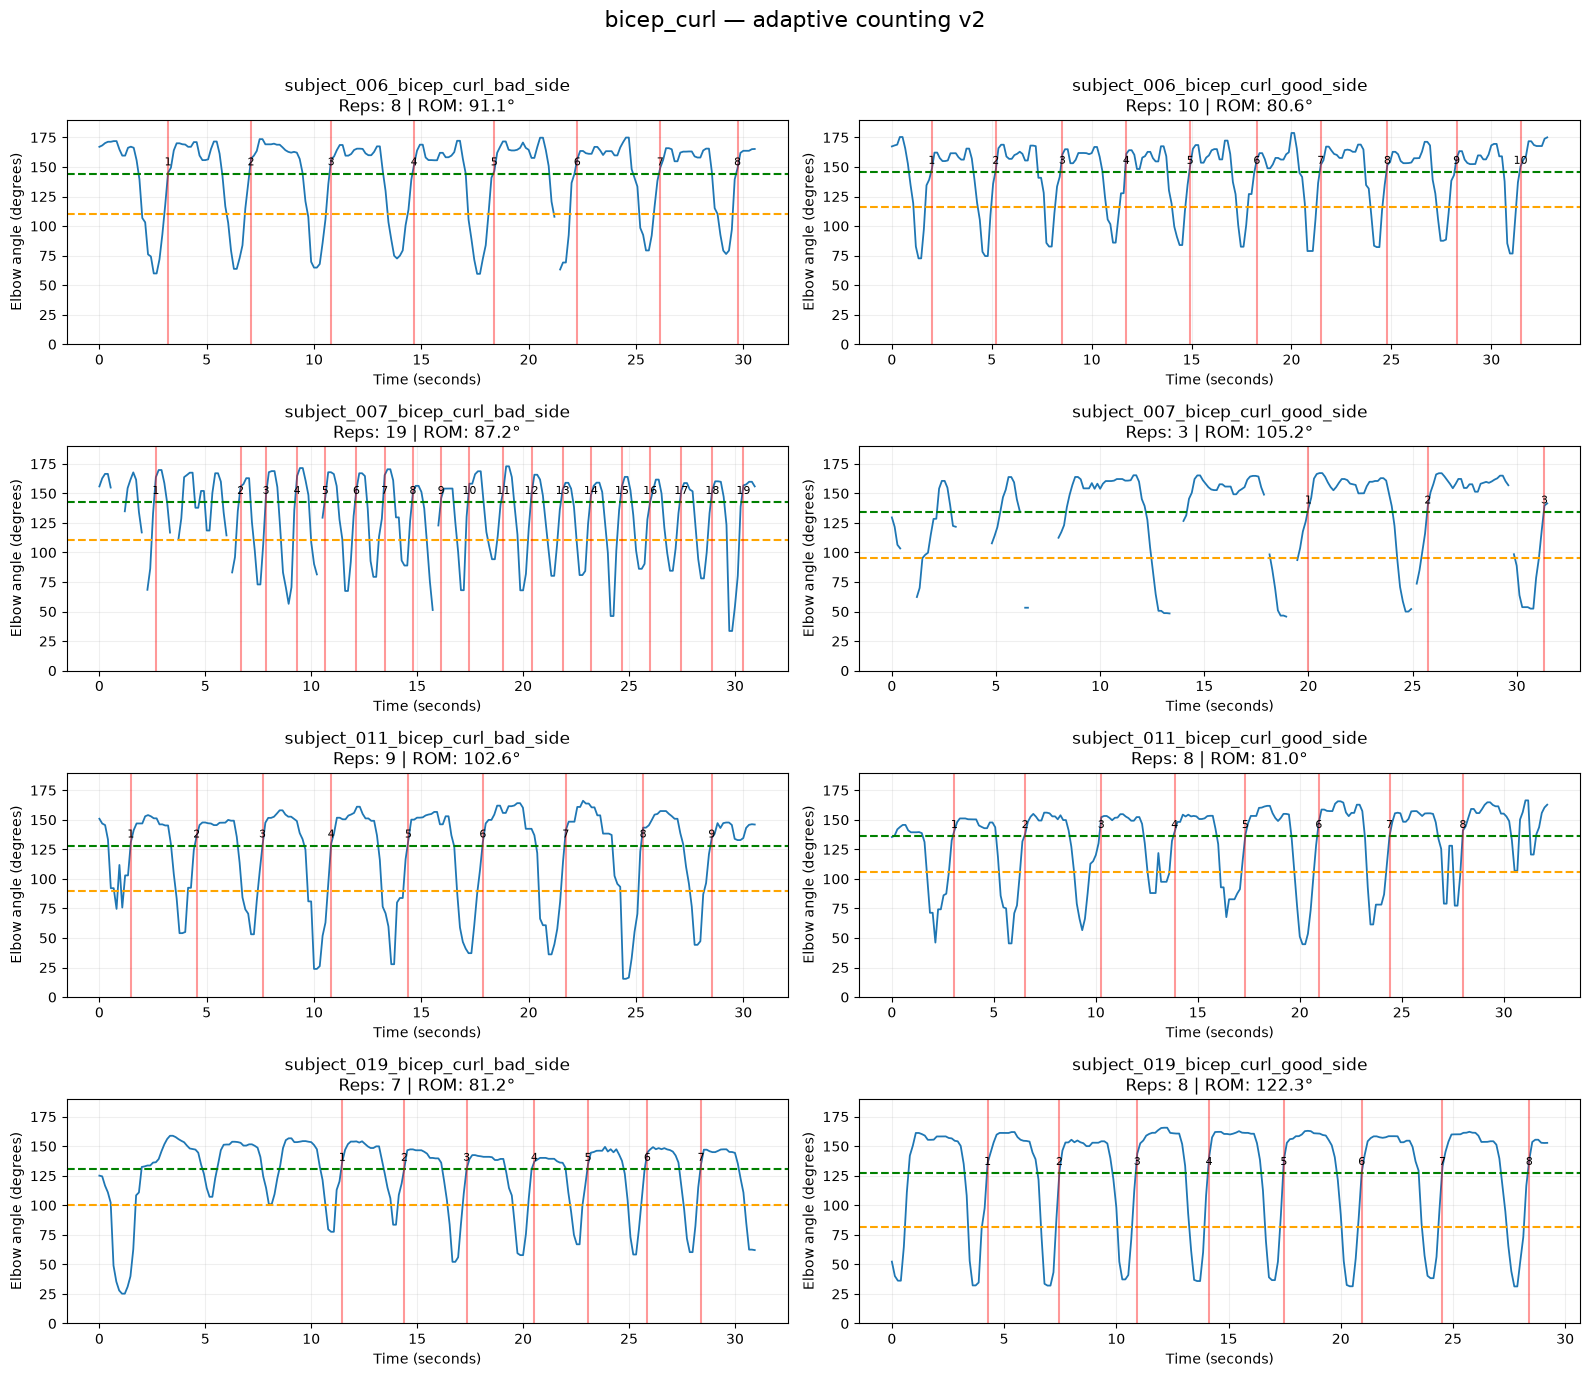

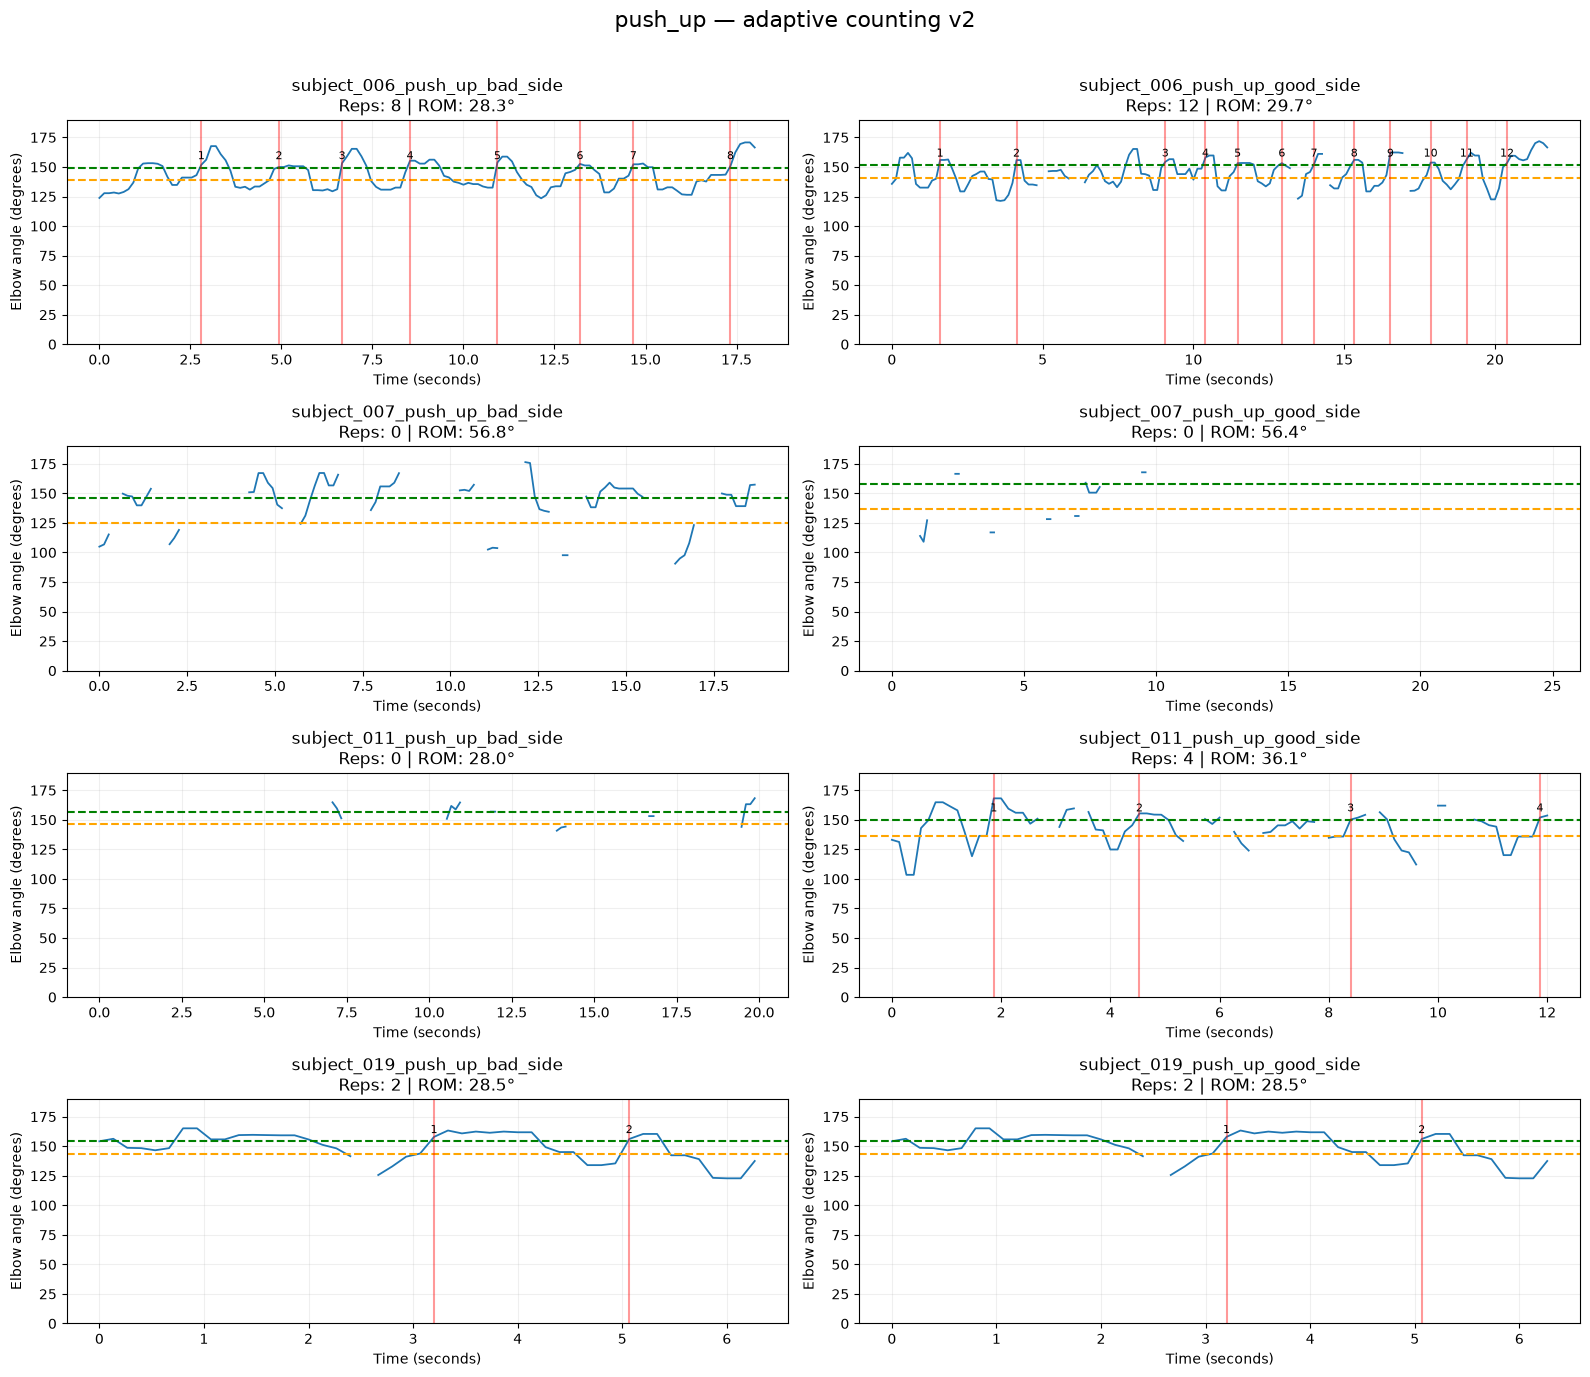

,video,exercise,valid_percent,range_of_motion,estimated_complete_reps_v1,estimated_complete_reps_v2,status
0,subject_006_bicep_curl_bad_side,bicep_curl,99.6,91.1,5,8,counted
1,subject_006_bicep_curl_good_side,bicep_curl,100.0,80.6,0,10,counted
2,subject_007_bicep_curl_bad_side,bicep_curl,96.1,87.2,8,19,counted
3,subject_007_bicep_curl_good_side,bicep_curl,84.8,105.2,2,3,counted
4,subject_011_bicep_curl_bad_side,bicep_curl,100.0,102.6,8,9,counted
5,subject_011_bicep_curl_good_side,bicep_curl,100.0,81.0,6,8,counted
6,subject_019_bicep_curl_bad_side,bicep_curl,100.0,81.2,3,7,counted
7,subject_019_bicep_curl_good_side,bicep_curl,100.0,122.3,8,8,counted
8,subject_006_push_up_bad_side,push_up,100.0,28.3,0,8,counted
9,subject_006_push_up_good_side,push_up,95.1,29.7,0,12,counted


Saved to: C:\GymProject\outputs\arm_reps_val_v1\adaptive_count_v2


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SOURCE = Path(r"C:\GymProject\outputs\arm_reps_val_v1")
OUTPUT = SOURCE / "adaptive_count_v2"
OUTPUT.mkdir(parents=True, exist_ok=True)

summary_v1 = pd.read_csv(SOURCE / "rep_summary.csv")

# أقل مجال حركة مقبول بالدرجات
MIN_ROM = {
    "bicep_curl": 35.0,
    "push_up": 18.0,
}

MIN_REP_SECONDS = 0.50
MAX_REP_SECONDS = 8.0
MAX_GAP_SECONDS = 0.35


def adaptive_thresholds(angles, exercise):
    valid = angles[np.isfinite(angles)]

    if len(valid) < 10:
        return np.nan, np.nan, np.nan

    # استخدام percentiles يقلل تأثير القيم الشاذة
    low = float(np.percentile(valid, 10))
    high = float(np.percentile(valid, 90))
    rom = high - low

    if rom < MIN_ROM[exercise]:
        return np.nan, np.nan, rom

    # حد الثني قريب من الجزء السفلي
    bent_threshold = low + 0.35 * rom

    # حد المد قريب من الجزء العلوي
    extended_threshold = low + 0.72 * rom

    return bent_threshold, extended_threshold, rom


def count_repetitions(
    times,
    angles,
    bent_threshold,
    extended_threshold,
):
    state = "seek_extended"
    last_valid_time = None
    last_extended_time = None
    rep_start = None
    minimum_angle = None
    events = []

    for time_s, angle in zip(times, angles):
        if not np.isfinite(angle):
            continue

        if (
            last_valid_time is not None
            and time_s - last_valid_time > MAX_GAP_SECONDS
        ):
            state = "seek_extended"
            last_extended_time = None
            rep_start = None
            minimum_angle = None

        last_valid_time = time_s

        if state == "seek_extended":
            if angle >= extended_threshold:
                state = "extended"
                last_extended_time = time_s

        elif state == "extended":
            if angle >= extended_threshold:
                last_extended_time = time_s

            elif angle <= bent_threshold:
                state = "bent"
                rep_start = last_extended_time
                minimum_angle = angle

        elif state == "bent":
            minimum_angle = min(minimum_angle, angle)

            if time_s - rep_start > MAX_REP_SECONDS:
                state = "seek_extended"
                rep_start = None
                minimum_angle = None

            elif angle >= extended_threshold:
                duration = time_s - rep_start

                if MIN_REP_SECONDS <= duration <= MAX_REP_SECONDS:
                    events.append({
                        "start_s": float(rep_start),
                        "end_s": float(time_s),
                        "duration_s": float(duration),
                        "minimum_angle": float(minimum_angle),
                    })

                state = "extended"
                last_extended_time = time_s
                rep_start = None
                minimum_angle = None

    return events


results = []
all_events = []
plots = []

for _, item in summary_v1.iterrows():
    name = item["video"]
    exercise = item["exercise"]

    signal_path = SOURCE / f"{name}_signal.csv"
    assert signal_path.is_file(), f"الملف غير موجود: {signal_path}"

    signal = pd.read_csv(signal_path)
    times = signal["time_s"].to_numpy(dtype=float)
    angles = signal["counting_angle"].to_numpy(dtype=float)

    bent, extended, rom = adaptive_thresholds(angles, exercise)

    if np.isfinite(bent) and np.isfinite(extended):
        events = count_repetitions(
            times,
            angles,
            bent_threshold=bent,
            extended_threshold=extended,
        )
        status = "counted"
    else:
        events = []
        status = "insufficient_motion"

    for rep, event in enumerate(events, start=1):
        all_events.append({
            "video": name,
            "exercise": exercise,
            "rep": rep,
            **event,
        })

    results.append({
        "video": name,
        "exercise": exercise,
        "side": item["side"],
        "valid_percent": item["valid_percent"],
        "range_of_motion": round(rom, 1),
        "bent_threshold": (
            round(bent, 1) if np.isfinite(bent) else np.nan
        ),
        "extended_threshold": (
            round(extended, 1) if np.isfinite(extended) else np.nan
        ),
        "estimated_complete_reps_v1":
            int(item["estimated_complete_reps"]),
        "estimated_complete_reps_v2": len(events),
        "status": status,
    })

    plots.append({
        "video": name,
        "exercise": exercise,
        "times": times,
        "angles": angles,
        "bent": bent,
        "extended": extended,
        "events": events,
        "rom": rom,
    })

results = pd.DataFrame(results)
events_df = pd.DataFrame(all_events)

results.to_csv(
    OUTPUT / "rep_summary_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

events_df.to_csv(
    OUTPUT / "rep_events_v2.csv",
    index=False,
    encoding="utf-8-sig",
)

for exercise in ["bicep_curl", "push_up"]:
    exercise_plots = [
        item for item in plots
        if item["exercise"] == exercise
    ]

    fig, axes = plt.subplots(4, 2, figsize=(16, 14))

    for ax, item in zip(axes.ravel(), exercise_plots):
        ax.plot(
            item["times"],
            item["angles"],
            linewidth=1.3,
            label="Elbow angle",
        )

        if np.isfinite(item["bent"]):
            ax.axhline(
                item["bent"],
                color="orange",
                linestyle="--",
                label="Bent threshold",
            )
            ax.axhline(
                item["extended"],
                color="green",
                linestyle="--",
                label="Extended threshold",
            )

        for number, event in enumerate(item["events"], start=1):
            ax.axvline(
                event["end_s"],
                color="red",
                alpha=0.40,
            )
            ax.annotate(
                str(number),
                (event["end_s"], item["extended"]),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=8,
            )

        ax.set_title(
            f"{item['video']}\n"
            f"Reps: {len(item['events'])} | "
            f"ROM: {item['rom']:.1f}°"
        )
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Elbow angle (degrees)")
        ax.set_ylim(0, 190)
        ax.grid(alpha=0.2)

    fig.suptitle(f"{exercise} — adaptive counting v2", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(
        OUTPUT / f"{exercise}_adaptive_counts.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

display(results[[
    "video",
    "exercise",
    "valid_percent",
    "range_of_motion",
    "estimated_complete_reps_v1",
    "estimated_complete_reps_v2",
    "status",
]])

print("Saved to:", OUTPUT)

In [3]:
from pathlib import Path
import os

ROOT = Path(r"C:\GymProject\data\Dataset Exercise Quality-wise")

VIDEOS = [
    ROOT / "bicep_curl" / "good" / "side"
    / "subject_006_bicep_curl_good_side.mp4",

    ROOT / "bicep_curl" / "bad" / "side"
    / "subject_007_bicep_curl_bad_side.mp4",

    ROOT / "push_up" / "good" / "side"
    / "subject_006_push_up_good_side.mp4",

    ROOT / "push_up" / "good" / "side"
    / "subject_019_push_up_good_side.mp4",
]

for video in VIDEOS:
    assert video.is_file(), f"الفيديو غير موجود: {video}"
    print(video.name)
    os.startfile(str(video))

subject_006_bicep_curl_good_side.mp4
subject_007_bicep_curl_bad_side.mp4
subject_006_push_up_good_side.mp4
subject_019_push_up_good_side.mp4


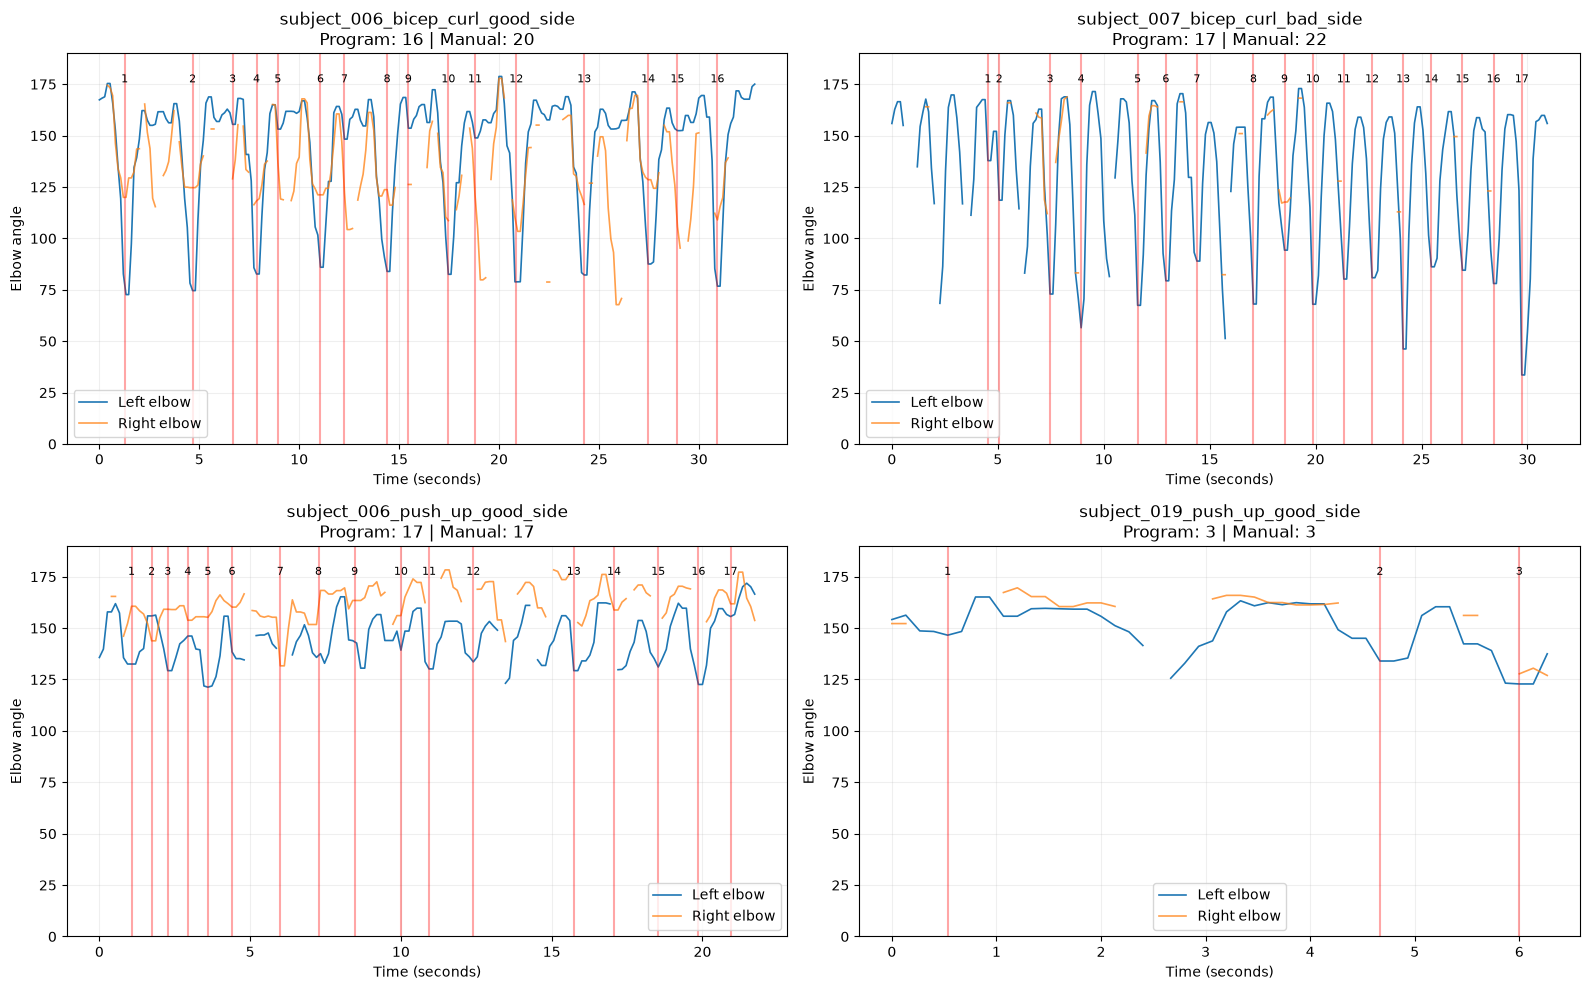

,video,left_detected_movements,right_detected_movements,predicted_reps_v3,manual_reps,absolute_error,status
1,subject_006_bicep_curl_good_side,16,4,16,20.0,4.0,usable
2,subject_007_bicep_curl_bad_side,17,0,17,22.0,5.0,usable
9,subject_006_push_up_good_side,11,8,17,17.0,0.0,usable
15,subject_019_push_up_good_side,3,0,3,3.0,0.0,usable


Mean Absolute Error: 2.25 reps
Exact agreement: 50.00%
Saved to: C:\GymProject\outputs\arm_reps_val_v1\peak_count_v3


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import display

SOURCE = Path(r"C:\GymProject\outputs\arm_reps_val_v1")
OUTPUT = SOURCE / "peak_count_v3"
OUTPUT.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(SOURCE / "rep_summary.csv")

MANUAL_COUNTS = {
    "subject_006_bicep_curl_good_side": 20,
    "subject_007_bicep_curl_bad_side": 22,
    "subject_006_push_up_good_side": 17,
    "subject_019_push_up_good_side": 3,
}

PARAMETERS = {
    "bicep_curl": {
        "minimum_prominence": 10.0,
        "prominence_ratio": 0.13,
        "minimum_distance_s": 0.55,
        "merge_sides_within_s": 0.40,
    },
    "push_up": {
        "minimum_prominence": 4.0,
        "prominence_ratio": 0.10,
        "minimum_distance_s": 0.50,
        "merge_sides_within_s": 0.45,
    },
}

MAX_GAP_SECONDS = 0.35
MIN_SIDE_COVERAGE = 0.40


def smooth_signal(times, raw):
    smoothed = np.full(len(raw), np.nan)
    start = 0

    while start < len(raw):
        if not np.isfinite(raw[start]):
            start += 1
            continue

        end = start + 1
        while (
            end < len(raw)
            and np.isfinite(raw[end])
            and times[end] - times[end - 1] <= MAX_GAP_SECONDS
        ):
            end += 1

        smoothed[start:end] = (
            pd.Series(raw[start:end])
            .rolling(3, center=True, min_periods=1)
            .median()
            .to_numpy()
        )
        start = end

    return smoothed


def detect_flexions(times, angles, exercise):
    valid_values = angles[np.isfinite(angles)]

    if len(valid_values) < 10:
        return [], np.nan, np.nan

    low = float(np.percentile(valid_values, 10))
    high = float(np.percentile(valid_values, 90))
    rom = high - low

    config = PARAMETERS[exercise]
    prominence = max(
        config["minimum_prominence"],
        config["prominence_ratio"] * rom,
    )

    events = []
    start = 0

    while start < len(angles):
        if not np.isfinite(angles[start]):
            start += 1
            continue

        end = start + 1
        while (
            end < len(angles)
            and np.isfinite(angles[end])
            and times[end] - times[end - 1] <= MAX_GAP_SECONDS
        ):
            end += 1

        segment_times = times[start:end]
        segment_angles = angles[start:end]

        if len(segment_angles) >= 5:
            dt = np.median(np.diff(segment_times))

            if np.isfinite(dt) and dt > 0:
                distance_samples = max(
                    1,
                    int(round(
                        config["minimum_distance_s"] / dt
                    )),
                )

                # قاع زاوية المرفق = أعلى نقطة ثني في الحركة
                peaks, properties = find_peaks(
                    -segment_angles,
                    prominence=prominence,
                    distance=distance_samples,
                )

                for local_index, event_prominence in zip(
                    peaks,
                    properties["prominences"],
                ):
                    global_index = start + int(local_index)

                    events.append({
                        "time_s": float(times[global_index]),
                        "angle": float(angles[global_index]),
                        "prominence": float(event_prominence),
                    })

        start = end

    return events, rom, prominence


def merge_bilateral_events(events, tolerance):
    """
    إذا تحرك الذراعان في نفس الوقت نحسب الحركة مرة واحدة.
    وإذا تحركا بالتبادل نحسب كل حركة مستقلة.
    """
    if not events:
        return []

    ordered = sorted(events, key=lambda event: event["time_s"])
    clusters = [[ordered[0]]]

    for event in ordered[1:]:
        cluster_center = np.mean([
            item["time_s"] for item in clusters[-1]
        ])

        if event["time_s"] - cluster_center <= tolerance:
            clusters[-1].append(event)
        else:
            clusters.append([event])

    merged = []

    for cluster in clusters:
        merged.append({
            "time_s": float(np.median([
                item["time_s"] for item in cluster
            ])),
            "angle": float(np.min([
                item["angle"] for item in cluster
            ])),
            "sides": "+".join(sorted(set(
                item["side"] for item in cluster
            ))),
            "prominence": float(np.max([
                item["prominence"] for item in cluster
            ])),
        })

    return merged


result_rows = []
event_rows = []
plot_items = []

for _, row in summary.iterrows():
    name = row["video"]
    exercise = row["exercise"]
    signal_path = SOURCE / f"{name}_signal.csv"

    assert signal_path.is_file(), f"غير موجود: {signal_path}"

    signal = pd.read_csv(signal_path)
    times = signal["time_s"].to_numpy(dtype=float)

    bilateral_events = []
    side_details = {}
    best_coverage = 0.0

    for side in ["left", "right"]:
        raw = signal[f"{side}_angle"].to_numpy(dtype=float)
        coverage = float(np.isfinite(raw).mean())
        best_coverage = max(best_coverage, coverage)

        smoothed = smooth_signal(times, raw)
        signal[f"{side}_smoothed_v3"] = smoothed

        side_events, rom, prominence = detect_flexions(
            times,
            smoothed,
            exercise,
        )

        side_details[side] = {
            "coverage": coverage,
            "rom": rom,
            "prominence": prominence,
            "events": side_events,
        }

        # الجهة ضعيفة القياس لا تدخل في الدمج
        if coverage >= MIN_SIDE_COVERAGE:
            for event in side_events:
                bilateral_events.append({
                    **event,
                    "side": side,
                })

    merged_events = merge_bilateral_events(
        bilateral_events,
        PARAMETERS[exercise]["merge_sides_within_s"],
    )

    if best_coverage >= 0.60:
        status = "usable"
    elif best_coverage >= 0.40:
        status = "review_required"
    else:
        status = "unreliable_pose"

    manual = MANUAL_COUNTS.get(name, np.nan)
    predicted = len(merged_events)

    result_rows.append({
        "video": name,
        "exercise": exercise,
        "left_valid_percent": round(
            side_details["left"]["coverage"] * 100, 1
        ),
        "right_valid_percent": round(
            side_details["right"]["coverage"] * 100, 1
        ),
        "left_detected_movements":
            len(side_details["left"]["events"]),
        "right_detected_movements":
            len(side_details["right"]["events"]),
        "predicted_reps_v3": predicted,
        "manual_reps": manual,
        "absolute_error": (
            abs(predicted - manual)
            if np.isfinite(manual) else np.nan
        ),
        "status": status,
    })

    for rep, event in enumerate(merged_events, start=1):
        event_rows.append({
            "video": name,
            "exercise": exercise,
            "rep": rep,
            **event,
        })

    signal.to_csv(
        OUTPUT / f"{name}_signal_v3.csv",
        index=False,
        encoding="utf-8-sig",
    )

    if name in MANUAL_COUNTS:
        plot_items.append({
            "video": name,
            "exercise": exercise,
            "times": times,
            "left": signal["left_smoothed_v3"].to_numpy(),
            "right": signal["right_smoothed_v3"].to_numpy(),
            "events": merged_events,
            "manual": int(manual),
        })

results_v3 = pd.DataFrame(result_rows)
events_v3 = pd.DataFrame(event_rows)

results_v3.to_csv(
    OUTPUT / "rep_summary_v3.csv",
    index=False,
    encoding="utf-8-sig",
)
events_v3.to_csv(
    OUTPUT / "rep_events_v3.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, item in zip(axes, plot_items):
    ax.plot(
        item["times"], item["left"],
        label="Left elbow", linewidth=1.2
    )
    ax.plot(
        item["times"], item["right"],
        label="Right elbow", linewidth=1.2, alpha=0.75
    )

    for number, event in enumerate(item["events"], start=1):
        ax.axvline(event["time_s"], color="red", alpha=0.35)
        ax.annotate(
            str(number),
            (event["time_s"], 180),
            ha="center",
            va="top",
            fontsize=8,
        )

    ax.set_title(
        f"{item['video']}\n"
        f"Program: {len(item['events'])} | "
        f"Manual: {item['manual']}"
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Elbow angle")
    ax.set_ylim(0, 190)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
fig.savefig(
    OUTPUT / "manual_comparison_v3.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

comparison = results_v3.loc[
    results_v3["manual_reps"].notna(),
    [
        "video",
        "left_detected_movements",
        "right_detected_movements",
        "predicted_reps_v3",
        "manual_reps",
        "absolute_error",
        "status",
    ],
]

display(comparison)

mae = comparison["absolute_error"].mean()
exact = (
    comparison["predicted_reps_v3"]
    == comparison["manual_reps"]
).mean()

print(f"Mean Absolute Error: {mae:.2f} reps")
print(f"Exact agreement: {exact:.2%}")
print("Saved to:", OUTPUT)

In [5]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
import torch
import time

PROJECT = Path(r"C:\GymProject")
PREPARED = PROJECT / "prepared" / "exercise_type_v1"
OUTPUT = PROJECT / "prepared" / "pose_quality_features_v1"
OUTPUT.mkdir(parents=True, exist_ok=True)

MANIFEST = PREPARED / "video_manifest.csv"
PARTIAL_FILE = OUTPUT / "pose_video_features_partial.csv"
FINAL_FILE = OUTPUT / "pose_video_features.csv"

POSE_CANDIDATES = [
    PROJECT / "yolo11s-pose.pt",
    Path.cwd() / "yolo11s-pose.pt",
]

POSE_WEIGHT = next(
    (path for path in POSE_CANDIDATES if path.is_file()),
    None
)

assert POSE_WEIGHT is not None, (
    "لم أجد yolo11s-pose.pt داخل C:\\GymProject "
    "أو بجانب ملف Jupyter"
)
assert MANIFEST.is_file(), f"الملف غير موجود: {MANIFEST}"
assert torch.cuda.is_available(), "GPU غير متاح."

videos = pd.read_csv(
    MANIFEST,
    dtype={"subject": str},
)

videos = videos.loc[
    videos["exercise"].isin([
        "squat",
        "push_up",
        "bicep_curl",
    ])
].copy()

assert len(videos) == 444, (
    f"المتوقع 444 فيديو، الموجود {len(videos)}"
)

pose = YOLO(str(POSE_WEIGHT))

TARGET_FPS = 5
IMAGE_SIZE = 640
PERSON_CONF = 0.20
KEYPOINT_CONF = 0.35

ANGLE_JOINTS = {
    "left_elbow": (5, 7, 9),
    "right_elbow": (6, 8, 10),

    "left_shoulder": (7, 5, 11),
    "right_shoulder": (8, 6, 12),

    "left_hip": (5, 11, 13),
    "right_hip": (6, 12, 14),

    "left_knee": (11, 13, 15),
    "right_knee": (12, 14, 16),

    "left_body": (5, 11, 15),
    "right_body": (6, 12, 16),
}

METRIC_NAMES = list(ANGLE_JOINTS) + [
    "elbow_mean",
    "knee_mean",
    "hip_mean",
    "body_mean",
    "elbow_difference",
    "knee_difference",
    "trunk_tilt",
]


def calculate_angle(point_a, point_b, point_c):
    vector_a = point_a - point_b
    vector_b = point_c - point_b

    denominator = (
        np.linalg.norm(vector_a)
        * np.linalg.norm(vector_b)
    )

    if denominator < 1e-6:
        return np.nan

    cosine = np.clip(
        np.dot(vector_a, vector_b) / denominator,
        -1.0,
        1.0,
    )

    return float(np.degrees(np.arccos(cosine)))


def calculate_trunk_tilt(keypoints, confidence):
    # متوسط الكتفين ومتوسط الوركين
    required = [5, 6, 11, 12]

    if np.min(confidence[required]) < KEYPOINT_CONF:
        return np.nan

    shoulder = np.mean(keypoints[[5, 6]], axis=0)
    hip = np.mean(keypoints[[11, 12]], axis=0)

    vector = shoulder - hip

    if np.linalg.norm(vector) < 1e-6:
        return np.nan

    # 0 درجة = الجذع رأسي
    angle = np.degrees(
        np.arctan2(abs(vector[0]), abs(vector[1]))
    )

    return float(angle)


def box_iou(previous_box, boxes):
    top_left = np.maximum(
        previous_box[:2],
        boxes[:, :2],
    )
    bottom_right = np.minimum(
        previous_box[2:],
        boxes[:, 2:],
    )

    intersection = np.prod(
        np.maximum(bottom_right - top_left, 0),
        axis=1,
    )

    previous_area = np.prod(
        np.maximum(
            previous_box[2:] - previous_box[:2],
            0,
        )
    )

    areas = np.prod(
        np.maximum(boxes[:, 2:] - boxes[:, :2], 0),
        axis=1,
    )

    return intersection / (
        previous_area + areas - intersection + 1e-8
    )


def choose_person(result, previous_box):
    if (
        result.boxes is None
        or len(result.boxes) == 0
        or result.keypoints is None
        or result.keypoints.conf is None
    ):
        return None, previous_box

    boxes = result.boxes.xyxy.cpu().numpy()

    if previous_box is not None:
        overlaps = box_iou(previous_box, boxes)

        if overlaps.max() >= 0.15:
            index = int(overlaps.argmax())
            return index, boxes[index].copy()

    # عند فقدان التتبع نختار أكبر شخص
    areas = np.prod(
        np.maximum(boxes[:, 2:] - boxes[:, :2], 0),
        axis=1,
    )

    index = int(areas.argmax())
    return index, boxes[index].copy()


def bilateral_mean(left, right):
    values = [
        value for value in [left, right]
        if np.isfinite(value)
    ]

    return float(np.mean(values)) if values else np.nan


def aggregate_metric(times, values, prefix):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)

    valid = np.isfinite(values)
    valid_values = values[valid]
    valid_times = times[valid]

    output = {
        f"{prefix}_valid_ratio": float(valid.mean())
        if len(values) else 0.0,
    }

    if len(valid_values) < 3:
        for suffix in [
            "mean", "std", "min", "max",
            "p10", "p25", "median", "p75", "p90",
            "range", "velocity_median", "velocity_p90",
        ]:
            output[f"{prefix}_{suffix}"] = np.nan

        return output

    percentiles = np.percentile(
        valid_values,
        [10, 25, 50, 75, 90],
    )

    output.update({
        f"{prefix}_mean": float(np.mean(valid_values)),
        f"{prefix}_std": float(np.std(valid_values)),
        f"{prefix}_min": float(np.min(valid_values)),
        f"{prefix}_max": float(np.max(valid_values)),
        f"{prefix}_p10": float(percentiles[0]),
        f"{prefix}_p25": float(percentiles[1]),
        f"{prefix}_median": float(percentiles[2]),
        f"{prefix}_p75": float(percentiles[3]),
        f"{prefix}_p90": float(percentiles[4]),
        f"{prefix}_range": float(
            percentiles[4] - percentiles[0]
        ),
    })

    time_difference = np.diff(valid_times)
    value_difference = np.abs(np.diff(valid_values))

    usable_velocity = (
        (time_difference > 0)
        & (time_difference <= 0.6)
    )

    velocities = (
        value_difference[usable_velocity]
        / time_difference[usable_velocity]
    )

    if len(velocities):
        output[f"{prefix}_velocity_median"] = float(
            np.median(velocities)
        )
        output[f"{prefix}_velocity_p90"] = float(
            np.percentile(velocities, 90)
        )
    else:
        output[f"{prefix}_velocity_median"] = np.nan
        output[f"{prefix}_velocity_p90"] = np.nan

    return output


def extract_video_features(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"تعذر فتح الفيديو: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    expected_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if not np.isfinite(fps) or fps <= 0:
        cap.release()
        raise ValueError(f"FPS غير صالح: {video_path}")

    stride = max(1, round(fps / TARGET_FPS))

    metric_times = {
        name: [] for name in METRIC_NAMES
    }
    metric_values = {
        name: [] for name in METRIC_NAMES
    }

    previous_box = None
    decoded_frames = 0
    sampled_frames = 0
    selected_frames = 0

    try:
        while True:
            ok, frame = cap.read()

            if not ok:
                break

            frame_index = decoded_frames
            decoded_frames += 1

            if frame_index % stride != 0:
                continue

            sampled_frames += 1
            current_time = frame_index / fps

            result = pose.predict(
                frame,
                imgsz=IMAGE_SIZE,
                conf=PERSON_CONF,
                device=0,
                verbose=False,
            )[0]

            person, previous_box = choose_person(
                result,
                previous_box,
            )

            frame_metrics = {
                name: np.nan for name in METRIC_NAMES
            }

            if person is not None:
                selected_frames += 1

                xy = (
                    result.keypoints.xy[person]
                    .cpu()
                    .numpy()
                )
                confidence = (
                    result.keypoints.conf[person]
                    .cpu()
                    .numpy()
                )

                for name, joints in ANGLE_JOINTS.items():
                    joint_indices = list(joints)
                    points = xy[joint_indices]

                    valid = (
                        np.min(confidence[joint_indices])
                        >= KEYPOINT_CONF
                        and np.isfinite(points).all()
                        and np.all(
                            np.linalg.norm(points, axis=1) > 0
                        )
                    )

                    if valid:
                        frame_metrics[name] = calculate_angle(
                            points[0],
                            points[1],
                            points[2],
                        )

                frame_metrics["elbow_mean"] = bilateral_mean(
                    frame_metrics["left_elbow"],
                    frame_metrics["right_elbow"],
                )
                frame_metrics["knee_mean"] = bilateral_mean(
                    frame_metrics["left_knee"],
                    frame_metrics["right_knee"],
                )
                frame_metrics["hip_mean"] = bilateral_mean(
                    frame_metrics["left_hip"],
                    frame_metrics["right_hip"],
                )
                frame_metrics["body_mean"] = bilateral_mean(
                    frame_metrics["left_body"],
                    frame_metrics["right_body"],
                )

                if (
                    np.isfinite(frame_metrics["left_elbow"])
                    and np.isfinite(
                        frame_metrics["right_elbow"]
                    )
                ):
                    frame_metrics["elbow_difference"] = abs(
                        frame_metrics["left_elbow"]
                        - frame_metrics["right_elbow"]
                    )

                if (
                    np.isfinite(frame_metrics["left_knee"])
                    and np.isfinite(
                        frame_metrics["right_knee"]
                    )
                ):
                    frame_metrics["knee_difference"] = abs(
                        frame_metrics["left_knee"]
                        - frame_metrics["right_knee"]
                    )

                frame_metrics["trunk_tilt"] = (
                    calculate_trunk_tilt(
                        xy,
                        confidence,
                    )
                )

            for name in METRIC_NAMES:
                metric_times[name].append(current_time)
                metric_values[name].append(
                    frame_metrics[name]
                )

    finally:
        cap.release()

    features = {
        "sampled_frames": sampled_frames,
        "decoded_frames": decoded_frames,
        "expected_frames": expected_frames,
        "person_selected_ratio": (
            selected_frames / sampled_frames
            if sampled_frames else 0.0
        ),
        "duration_s": (
            decoded_frames / fps if fps > 0 else np.nan
        ),
    }

    for name in METRIC_NAMES:
        features.update(
            aggregate_metric(
                metric_times[name],
                metric_values[name],
                name,
            )
        )

    return features


# استكمال العمل السابق إن كان موجودًا
if PARTIAL_FILE.is_file():
    completed = pd.read_csv(
        PARTIAL_FILE,
        dtype={"subject": str},
    )
    processed_paths = set(
        completed["path"].astype(str)
    )
    records = completed.to_dict("records")

    print(
        f"سيتم الاستكمال: "
        f"{len(processed_paths)}/444 فيديو مكتمل"
    )
else:
    processed_paths = set()
    records = []

start_time = time.time()

for number, (_, video) in enumerate(
    videos.iterrows(),
    start=1,
):
    video_path = str(video["path"])

    if video_path in processed_paths:
        continue

    try:
        features = extract_video_features(
            Path(video_path)
        )

        record = {
            "path": video_path,
            "subject": video["subject"],
            "exercise": video["exercise"],
            "quality": video["quality"],
            "view": video["view"],
            "split": video["split"],
            **features,
        }

        records.append(record)
        processed_paths.add(video_path)

    except Exception as error:
        print(
            f"ERROR: {Path(video_path).name}: {error}",
            flush=True,
        )
        continue

    # حفظ نقطة استكمال بعد كل فيديو
    pd.DataFrame(records).to_csv(
        PARTIAL_FILE,
        index=False,
        encoding="utf-8-sig",
    )

    completed_count = len(processed_paths)
    elapsed_minutes = (time.time() - start_time) / 60

    print(
        f"Processed {completed_count}/444 | "
        f"{Path(video_path).name} | "
        f"{elapsed_minutes:.1f} min",
        flush=True,
    )

features_df = pd.DataFrame(records)

assert len(features_df) == 444, (
    f"اكتمل {len(features_df)} من 444 فيديو. "
    "شغّل الخلية مجددًا لإكمال الملفات التي أخطأت."
)

features_df.to_csv(
    FINAL_FILE,
    index=False,
    encoding="utf-8-sig",
)

print("\nتم استخراج الخصائص بنجاح.")
print("عدد الفيديوهات:", len(features_df))
print("عدد الخصائص:", len(features_df.columns))
print("الملف النهائي:", FINAL_FILE)

display(
    features_df.groupby(
        ["split", "exercise", "quality"]
    ).size().unstack(fill_value=0)
)

Processed 1/444 | subject_001_bicep_curl_bad_diagonal.mp4 | 0.1 min
Processed 2/444 | subject_002_bicep_curl_bad_diagonal.mp4 | 0.2 min
Processed 3/444 | subject_003_bicep_curl_bad_diagonal.mp4 | 0.2 min
Processed 4/444 | subject_004_bicep_curl_bad_diagonal.mp4 | 0.3 min
Processed 5/444 | subject_005_bicep_curl_bad_diagonal.mp4 | 0.4 min
Processed 6/444 | subject_006_bicep_curl_bad_diagonal.mp4 | 0.4 min
Processed 7/444 | subject_007_bicep_curl_bad_diagonal.mp4 | 0.5 min
Processed 8/444 | subject_008_bicep_curl_bad_diagonal.mp4 | 0.6 min
Processed 9/444 | subject_009_bicep_curl_bad_diagonal.mp4 | 0.6 min
Processed 10/444 | subject_010_bicep_curl_bad_diagonal.mp4 | 0.7 min
Processed 11/444 | subject_011_bicep_curl_bad_diagonal.mp4 | 0.7 min
Processed 12/444 | subject_012_bicep_curl_bad_diagonal.mp4 | 0.8 min
Processed 13/444 | subject_013_bicep_curl_bad_diagonal.mp4 | 0.8 min
Processed 14/444 | subject_014_bicep_curl_bad_diagonal.mp4 | 0.9 min
Processed 15/444 | subject_015_bicep_curl_b

quality           bad  good
split exercise             
test  bicep_curl   12    12
      push_up      12    12
      squat        12    12
train bicep_curl   51    51
      push_up      48    48
      squat        51    51
val   bicep_curl   12    12
      push_up      12    12
      squat        12    12

C:\Users\MATTHEW\AppData\Local\Temp\ipykernel_16884\3602375541.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["target"] = data["quality"].map({



squat
  Best model: forest_depth3_leaf2
  Validation accuracy: 58.33%
  Test accuracy: 79.17%

push_up
  Best model: logistic_C0.3
  Validation accuracy: 62.50%
  Test accuracy: 62.50%

bicep_curl
  Best model: forest_depth5_leaf4
  Validation accuracy: 79.17%
  Test accuracy: 58.33%


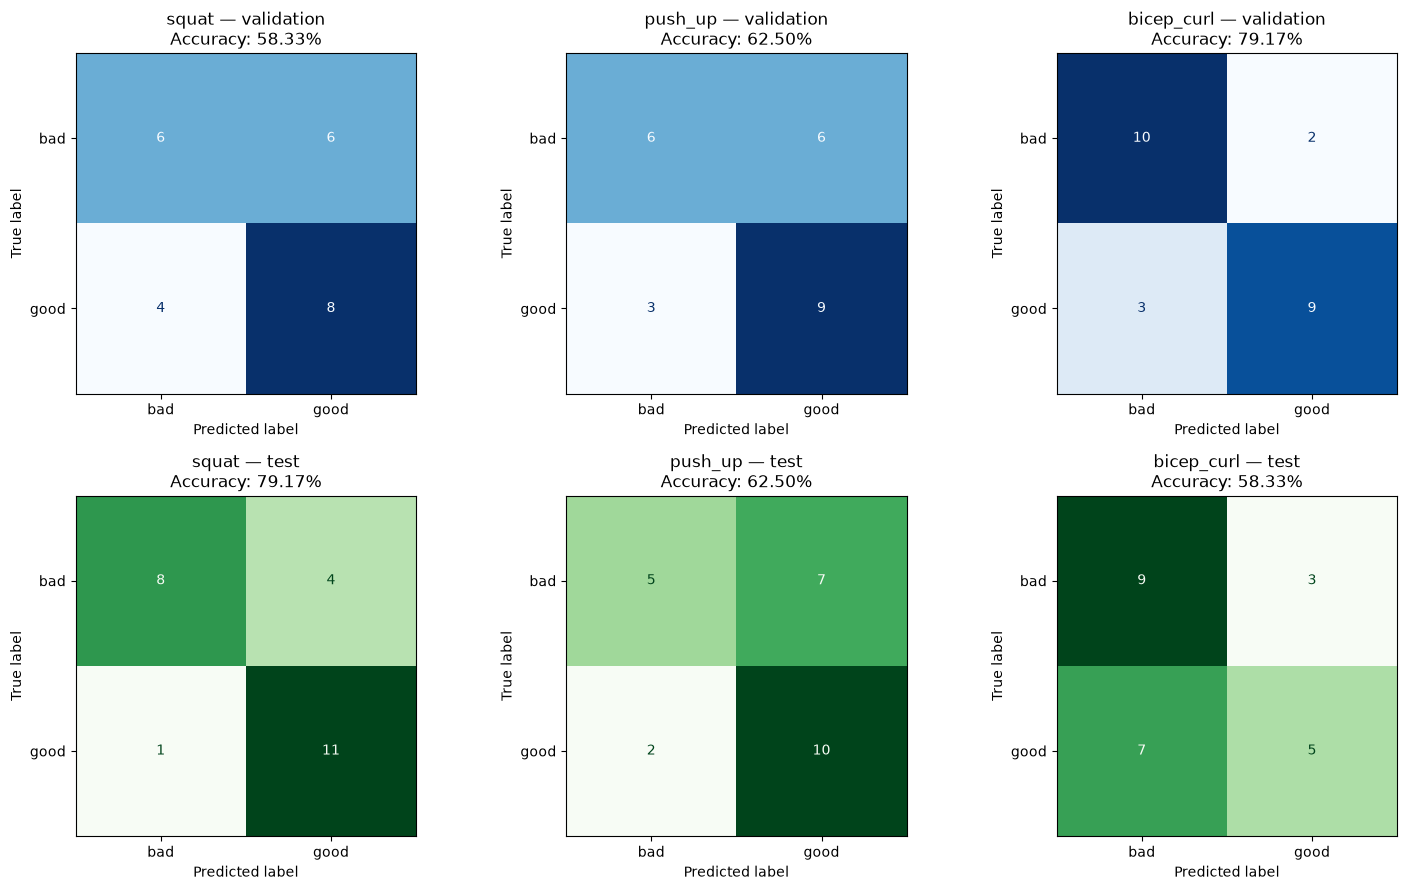

,exercise,selected_model,numeric_features,val_accuracy,val_balanced_accuracy,val_f1_good,test_accuracy,test_balanced_accuracy,test_f1_good
0,squat,forest_depth3_leaf2,222,58.33%,58.33%,61.54%,79.17%,79.17%,81.48%
1,push_up,logistic_C0.3,222,62.50%,62.50%,66.67%,62.50%,62.50%,68.97%
2,bicep_curl,forest_depth5_leaf4,222,79.17%,79.17%,78.26%,58.33%,58.33%,50.00%



تم حفظ النماذج في: C:\GymProject\models\quality_models_v1


In [6]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

PROJECT = Path(r"C:\GymProject")
FEATURE_FILE = (
    PROJECT / "prepared" / "pose_quality_features_v1"
    / "pose_video_features.csv"
)
OUTPUT = PROJECT / "models" / "quality_models_v1"
OUTPUT.mkdir(parents=True, exist_ok=True)

assert FEATURE_FILE.is_file(), (
    f"ملف الخصائص غير موجود: {FEATURE_FILE}"
)

data = pd.read_csv(
    FEATURE_FILE,
    dtype={"subject": str},
)

assert len(data) == 444
assert set(data["split"]) == {"train", "val", "test"}
assert set(data["quality"]) == {"good", "bad"}

# 1 = good، 0 = bad
data["target"] = data["quality"].map({
    "bad": 0,
    "good": 1,
})

EXERCISES = [
    "squat",
    "push_up",
    "bicep_curl",
]

# معلومات لا نريد للنموذج الاعتماد عليها في الحكم
EXCLUDED_COLUMNS = {
    "path",
    "subject",
    "exercise",
    "quality",
    "split",
    "target",
    "sampled_frames",
    "decoded_frames",
    "expected_frames",
    "duration_s",
}

CATEGORICAL_COLUMNS = ["view"]

all_results = []
saved_metadata = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))


def make_preprocessor(numeric_columns, scale):
    if scale:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
    else:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_columns,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_COLUMNS,
        ),
    ])


for column_index, exercise in enumerate(EXERCISES):
    exercise_data = data.loc[
        data["exercise"] == exercise
    ].copy()

    train = exercise_data.loc[
        exercise_data["split"] == "train"
    ].copy()
    val = exercise_data.loc[
        exercise_data["split"] == "val"
    ].copy()
    test = exercise_data.loc[
        exercise_data["split"] == "test"
    ].copy()

    # أعمدة الخصائص الرقمية
    candidate_numeric = [
        column for column in data.columns
        if column not in EXCLUDED_COLUMNS
        and column not in CATEGORICAL_COLUMNS
        and pd.api.types.is_numeric_dtype(data[column])
    ]

    # حذف الخاصية إذا كان أكثر من 60% منها مفقودًا في train
    numeric_columns = [
        column for column in candidate_numeric
        if train[column].notna().mean() >= 0.40
        and train[column].nunique(dropna=True) > 1
    ]

    input_columns = numeric_columns + CATEGORICAL_COLUMNS

    X_train = train[input_columns]
    y_train = train["target"]

    X_val = val[input_columns]
    y_val = val["target"]

    X_test = test[input_columns]
    y_test = test["target"]

    candidates = []

    # Logistic Regression: مناسب للبيانات الصغيرة
    for c_value in [0.03, 0.1, 0.3, 1.0]:
        candidates.append((
            f"logistic_C{c_value}",
            Pipeline([
                (
                    "preprocessor",
                    make_preprocessor(
                        numeric_columns,
                        scale=True,
                    ),
                ),
                (
                    "model",
                    LogisticRegression(
                        C=c_value,
                        max_iter=5000,
                        class_weight="balanced",
                        random_state=42,
                    ),
                ),
            ]),
        ))

    # Random Forest: يلتقط العلاقات غير الخطية
    for max_depth in [3, 5, None]:
        for min_leaf in [2, 4]:
            depth_name = (
                "none"
                if max_depth is None
                else str(max_depth)
            )

            candidates.append((
                f"forest_depth{depth_name}_leaf{min_leaf}",
                Pipeline([
                    (
                        "preprocessor",
                        make_preprocessor(
                            numeric_columns,
                            scale=False,
                        ),
                    ),
                    (
                        "model",
                        RandomForestClassifier(
                            n_estimators=500,
                            max_depth=max_depth,
                            min_samples_leaf=min_leaf,
                            max_features="sqrt",
                            class_weight="balanced",
                            random_state=42,
                            n_jobs=-1,
                        ),
                    ),
                ]),
            ))

    validation_rows = []
    best_name = None
    best_pipeline = None
    best_score = (-1, -1)

    for candidate_name, pipeline in candidates:
        pipeline.fit(X_train, y_train)
        val_prediction = pipeline.predict(X_val)

        val_balanced_accuracy = balanced_accuracy_score(
            y_val,
            val_prediction,
        )
        val_f1 = f1_score(
            y_val,
            val_prediction,
            zero_division=0,
        )
        val_accuracy = accuracy_score(
            y_val,
            val_prediction,
        )

        validation_rows.append({
            "exercise": exercise,
            "candidate": candidate_name,
            "val_accuracy": val_accuracy,
            "val_balanced_accuracy":
                val_balanced_accuracy,
            "val_f1_good": val_f1,
        })

        candidate_score = (
            val_balanced_accuracy,
            val_f1,
        )

        if candidate_score > best_score:
            best_score = candidate_score
            best_name = candidate_name
            best_pipeline = clone(pipeline)

    validation_results = pd.DataFrame(
        validation_rows
    ).sort_values(
        [
            "val_balanced_accuracy",
            "val_f1_good",
        ],
        ascending=False,
    )

    validation_results.to_csv(
        OUTPUT / f"{exercise}_validation_candidates.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # تقييم الفائز على val قبل إعادة التدريب
    best_pipeline.fit(X_train, y_train)
    val_prediction = best_pipeline.predict(X_val)

    val_accuracy = accuracy_score(
        y_val,
        val_prediction,
    )
    val_balanced_accuracy = balanced_accuracy_score(
        y_val,
        val_prediction,
    )
    val_f1 = f1_score(
        y_val,
        val_prediction,
        zero_division=0,
    )
    val_matrix = confusion_matrix(
        y_val,
        val_prediction,
        labels=[0, 1],
    )

    # تثبيت الإعداد ثم التدريب على train + val
    train_val = pd.concat(
        [train, val],
        ignore_index=True,
    )

    X_train_val = train_val[input_columns]
    y_train_val = train_val["target"]

    final_pipeline = clone(best_pipeline)
    final_pipeline.fit(
        X_train_val,
        y_train_val,
    )

    # فتح test مرة واحدة بعد تثبيت كل القرارات
    test_prediction = final_pipeline.predict(X_test)

    test_accuracy = accuracy_score(
        y_test,
        test_prediction,
    )
    test_balanced_accuracy = balanced_accuracy_score(
        y_test,
        test_prediction,
    )
    test_f1 = f1_score(
        y_test,
        test_prediction,
        zero_division=0,
    )
    test_matrix = confusion_matrix(
        y_test,
        test_prediction,
        labels=[0, 1],
    )

    model_path = OUTPUT / f"{exercise}_quality_model.joblib"

    model_package = {
        "exercise": exercise,
        "model": final_pipeline,
        "input_columns": input_columns,
        "numeric_columns": numeric_columns,
        "categorical_columns": CATEGORICAL_COLUMNS,
        "label_mapping": {
            0: "bad",
            1: "good",
        },
        "selected_candidate": best_name,
        "validation_metrics": {
            "accuracy": val_accuracy,
            "balanced_accuracy":
                val_balanced_accuracy,
            "f1_good": val_f1,
        },
        "test_metrics": {
            "accuracy": test_accuracy,
            "balanced_accuracy":
                test_balanced_accuracy,
            "f1_good": test_f1,
        },
    }

    joblib.dump(
        model_package,
        model_path,
    )

    saved_metadata[exercise] = {
        "model_path": str(model_path),
        "selected_candidate": best_name,
        "number_of_numeric_features":
            len(numeric_columns),
        "validation_accuracy": val_accuracy,
        "validation_balanced_accuracy":
            val_balanced_accuracy,
        "validation_f1_good": val_f1,
        "test_accuracy": test_accuracy,
        "test_balanced_accuracy":
            test_balanced_accuracy,
        "test_f1_good": test_f1,
    }

    all_results.append({
        "exercise": exercise,
        "selected_model": best_name,
        "numeric_features": len(numeric_columns),
        "val_accuracy": val_accuracy,
        "val_balanced_accuracy":
            val_balanced_accuracy,
        "val_f1_good": val_f1,
        "test_accuracy": test_accuracy,
        "test_balanced_accuracy":
            test_balanced_accuracy,
        "test_f1_good": test_f1,
    })

    ConfusionMatrixDisplay(
        confusion_matrix=val_matrix,
        display_labels=["bad", "good"],
    ).plot(
        ax=axes[0, column_index],
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )
    axes[0, column_index].set_title(
        f"{exercise} — validation\n"
        f"Accuracy: {val_accuracy:.2%}"
    )

    ConfusionMatrixDisplay(
        confusion_matrix=test_matrix,
        display_labels=["bad", "good"],
    ).plot(
        ax=axes[1, column_index],
        cmap="Greens",
        colorbar=False,
        values_format="d",
    )
    axes[1, column_index].set_title(
        f"{exercise} — test\n"
        f"Accuracy: {test_accuracy:.2%}"
    )

    print(
        f"\n{exercise}"
        f"\n  Best model: {best_name}"
        f"\n  Validation accuracy: {val_accuracy:.2%}"
        f"\n  Test accuracy: {test_accuracy:.2%}"
    )

plt.tight_layout()
fig.savefig(
    OUTPUT / "quality_confusion_matrices.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

results = pd.DataFrame(all_results)
results.to_csv(
    OUTPUT / "quality_model_results.csv",
    index=False,
    encoding="utf-8-sig",
)

with open(
    OUTPUT / "quality_models_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        saved_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

display(
    results.style.format({
        "val_accuracy": "{:.2%}",
        "val_balanced_accuracy": "{:.2%}",
        "val_f1_good": "{:.2%}",
        "test_accuracy": "{:.2%}",
        "test_balanced_accuracy": "{:.2%}",
        "test_f1_good": "{:.2%}",
    })
)

print("\nتم حفظ النماذج في:", OUTPUT)

In [7]:
from pathlib import Path
from datetime import datetime
import os
import shutil
import pandas as pd
import torch

from ultralytics import YOLO
from IPython.display import display

PROJECT = Path(r"C:\GymProject")
SOURCE = PROJECT / "prepared" / "exercise_type_v1"
QUALITY_DATA = PROJECT / "prepared" / "exercise_quality_v1"

IMAGE_MANIFEST = SOURCE / "image_manifest.csv"
VIDEO_MANIFEST = SOURCE / "video_manifest.csv"

assert IMAGE_MANIFEST.is_file()
assert VIDEO_MANIFEST.is_file()
assert torch.cuda.is_available()

images = pd.read_csv(
    IMAGE_MANIFEST,
    dtype={"subject": str},
)
videos = pd.read_csv(
    VIDEO_MANIFEST,
    dtype={"subject": str},
)

# ربط كل صورة بجودة الفيديو الأصلي
video_labels = videos[
    ["path", "quality"]
].rename(columns={"path": "video"})

dataset = images.merge(
    video_labels,
    on="video",
    how="left",
    validate="many_to_one",
)

assert dataset["quality"].notna().all()
assert len(dataset) == 5328

dataset["class_name"] = (
    dataset["exercise"]
    + "_"
    + dataset["quality"]
)

expected_classes = {
    "bicep_curl_bad",
    "bicep_curl_good",
    "push_up_bad",
    "push_up_good",
    "squat_bad",
    "squat_good",
}

assert set(dataset["class_name"]) == expected_classes

created = 0
existing = 0
copied_instead_of_linked = 0

for row in dataset.itertuples(index=False):
    source_image = Path(row.image)

    destination_dir = (
        QUALITY_DATA / row.split / row.class_name
    )
    destination_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    destination = destination_dir / source_image.name

    assert source_image.is_file(), (
        f"الصورة غير موجودة: {source_image}"
    )

    if destination.is_file():
        existing += 1
        continue

    try:
        # Hard link: لا يكرر مساحة الصورة
        os.link(source_image, destination)
    except OSError:
        # بديل إذا منع Windows إنشاء الرابط
        shutil.copy2(source_image, destination)
        copied_instead_of_linked += 1

    created += 1

print("New files:", created)
print("Already existed:", existing)
print("Copied instead of linked:", copied_instead_of_linked)

# فحص أعداد الصور
counts = (
    dataset.groupby(
        ["split", "class_name"]
    )
    .size()
    .unstack(fill_value=0)
)

display(counts)

for split in ["train", "val", "test"]:
    actual = sum(
        1 for _ in (QUALITY_DATA / split).glob("*/*.jpg")
    )
    expected = int(
        (dataset["split"] == split).sum()
    )

    assert actual == expected, (
        f"{split}: المتوقع {expected}، الموجود {actual}"
    )

print("\nDataset ready:", QUALITY_DATA)

# بدء تدريب YOLO11 المخصص للجودة
run_name = (
    "exercise_quality_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
)

quality_model = YOLO("yolo11n-cls.pt")

training_results = quality_model.train(
    data=str(QUALITY_DATA),
    epochs=35,
    patience=10,
    imgsz=320,
    batch=16,
    device=0,
    workers=0,
    project=str(PROJECT / "runs"),
    name=run_name,
    seed=42,
    val=True,
    save=True,
    plots=True,
    cache=False,
    amp=False,

    # الصور مجهزة مسبقًا كـ letterbox مربع
    scale=0.0,
    fliplr=0.5,
    flipud=0.0,
    auto_augment=None,
    erasing=0.0,
)

run_directory = Path(training_results.save_dir)

print("\nTraining finished")
print("Run directory:", run_directory)
print(
    "Best weights:",
    run_directory / "weights" / "best.pt",
)

New files: 5328
Already existed: 0
Copied instead of linked: 0


class_name,bicep_curl_bad,bicep_curl_good,push_up_bad,push_up_good,squat_bad,squat_good
split,,,,,,
test,144,144,144,144,144,144
train,612,612,576,576,612,612
val,144,144,144,144,144,144



Dataset ready: C:\GymProject\prepared\exercise_quality_v1
Ultralytics 8.4.157  Python-3.13.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\GymProject\prepared\exercise_quality_v1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, mom

Subject columns after merge: ['subject_x', 'subject_y']

Image-level 6-class accuracy: 43.98%
Video-level 6-class accuracy: 44.44%
Video exercise accuracy: 90.28%
Video quality accuracy with known exercise: 48.61%

Quality classification report:
              precision    recall  f1-score   support

         bad     0.4865    0.5000    0.4932        36
        good     0.4857    0.4722    0.4789        36

    accuracy                         0.4861        72
   macro avg     0.4861    0.4861    0.4860        72
weighted avg     0.4861    0.4861    0.4860        72



,exercise,correct,videos,quality_accuracy
0,bicep_curl,11,24,45.83%
1,push_up,14,24,58.33%
2,squat,10,24,41.67%


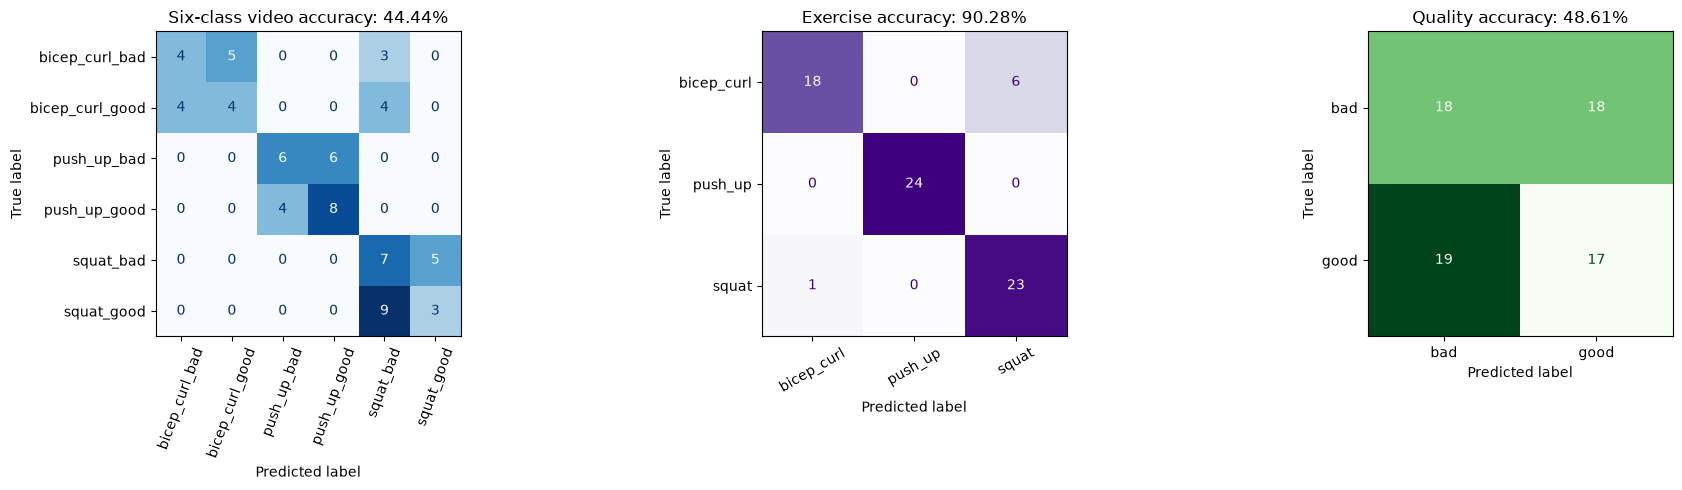


Saved to: C:\GymProject\runs\exercise_quality_20260921_194251\video_test_evaluation


In [9]:
# تأكيد سبب الخطأ
duplicate_subject_columns = [
    column for column in test_images.columns
    if column.startswith("subject")
]
print("Subject columns after merge:", duplicate_subject_columns)

assert "subject" not in test_images.columns
assert {
    "subject_x",
    "subject_y",
}.intersection(test_images.columns)

# إعادة حساب دقة الصور
image_accuracy = accuracy_score(
    test_images["true_class"],
    test_images["predicted_image_class"],
)

probability_columns = [
    f"prob_{name}" for name in class_names
]

# التجميع لا يحتاج subject أو view
video_results = (
    test_images.groupby(
        [
            "video",
            "true_exercise",
            "true_quality",
            "true_class",
        ],
        as_index=False,
    )[probability_columns]
    .mean()
)

assert len(video_results) == 72, (
    f"المتوقع 72 فيديو، الموجود {len(video_results)}"
)

video_probability_matrix = (
    video_results[probability_columns]
    .to_numpy()
)

video_results["predicted_class"] = [
    class_names[index]
    for index in video_probability_matrix.argmax(axis=1)
]

video_results["predicted_exercise_6class"] = (
    video_results["predicted_class"]
    .str.rsplit("_", n=1)
    .str[0]
)

video_results["predicted_quality_6class"] = (
    video_results["predicted_class"]
    .str.rsplit("_", n=1)
    .str[1]
)

# حساب نوع التمرين بجمع احتمال good وbad
exercise_names = [
    "bicep_curl",
    "push_up",
    "squat",
]

exercise_scores = np.column_stack([
    (
        video_results[f"prob_{exercise}_bad"]
        + video_results[f"prob_{exercise}_good"]
    ).to_numpy()
    for exercise in exercise_names
])

video_results["predicted_exercise"] = [
    exercise_names[index]
    for index in exercise_scores.argmax(axis=1)
]

# قياس الجودة مع معرفة نوع التمرين
predicted_qualities = []
quality_confidences = []

for _, row in video_results.iterrows():
    exercise = row["true_exercise"]

    bad_probability = row[
        f"prob_{exercise}_bad"
    ]
    good_probability = row[
        f"prob_{exercise}_good"
    ]

    pair_total = bad_probability + good_probability

    normalized_good = (
        good_probability / pair_total
        if pair_total > 0
        else 0.5
    )

    predicted_qualities.append(
        "good" if normalized_good >= 0.5 else "bad"
    )
    quality_confidences.append(
        max(normalized_good, 1 - normalized_good)
    )

video_results["predicted_quality"] = (
    predicted_qualities
)
video_results["quality_confidence"] = (
    quality_confidences
)

combined_accuracy = accuracy_score(
    video_results["true_class"],
    video_results["predicted_class"],
)

exercise_accuracy = accuracy_score(
    video_results["true_exercise"],
    video_results["predicted_exercise"],
)

quality_accuracy = accuracy_score(
    video_results["true_quality"],
    video_results["predicted_quality"],
)

print(
    f"\nImage-level 6-class accuracy: "
    f"{image_accuracy:.2%}"
)
print(
    f"Video-level 6-class accuracy: "
    f"{combined_accuracy:.2%}"
)
print(
    f"Video exercise accuracy: "
    f"{exercise_accuracy:.2%}"
)
print(
    "Video quality accuracy with known exercise: "
    f"{quality_accuracy:.2%}"
)

print("\nQuality classification report:")
print(classification_report(
    video_results["true_quality"],
    video_results["predicted_quality"],
    labels=["bad", "good"],
    digits=4,
    zero_division=0,
))

per_exercise_rows = []

for exercise in exercise_names:
    subset = video_results.loc[
        video_results["true_exercise"] == exercise
    ]

    correct = int(
        (
            subset["true_quality"]
            == subset["predicted_quality"]
        ).sum()
    )

    per_exercise_rows.append({
        "exercise": exercise,
        "correct": correct,
        "videos": len(subset),
        "quality_accuracy": accuracy_score(
            subset["true_quality"],
            subset["predicted_quality"],
        ),
    })

per_exercise = pd.DataFrame(per_exercise_rows)

display(
    per_exercise.style.format({
        "quality_accuracy": "{:.2%}",
    })
)

test_images.to_csv(
    OUTPUT / "image_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

video_results.to_csv(
    OUTPUT / "video_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

per_exercise.to_csv(
    OUTPUT / "per_exercise_quality.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

combined_matrix = confusion_matrix(
    video_results["true_class"],
    video_results["predicted_class"],
    labels=class_names,
)

ConfusionMatrixDisplay(
    combined_matrix,
    display_labels=class_names,
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

axes[0].set_title(
    f"Six-class video accuracy: "
    f"{combined_accuracy:.2%}"
)
axes[0].tick_params(axis="x", rotation=70)

exercise_matrix = confusion_matrix(
    video_results["true_exercise"],
    video_results["predicted_exercise"],
    labels=exercise_names,
)

ConfusionMatrixDisplay(
    exercise_matrix,
    display_labels=exercise_names,
).plot(
    ax=axes[1],
    cmap="Purples",
    colorbar=False,
    values_format="d",
)

axes[1].set_title(
    f"Exercise accuracy: {exercise_accuracy:.2%}"
)
axes[1].tick_params(axis="x", rotation=30)

quality_matrix = confusion_matrix(
    video_results["true_quality"],
    video_results["predicted_quality"],
    labels=["bad", "good"],
)

ConfusionMatrixDisplay(
    quality_matrix,
    display_labels=["bad", "good"],
).plot(
    ax=axes[2],
    cmap="Greens",
    colorbar=False,
    values_format="d",
)

axes[2].set_title(
    f"Quality accuracy: {quality_accuracy:.2%}"
)

plt.tight_layout()

figure_path = (
    OUTPUT / "video_evaluation_matrices.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("\nSaved to:", OUTPUT)

c:\Users\MATTHEW\gym-yolo-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: you may need to restart the kernel to use updated packages.
Dataset: C:\GymProject\prepared\exercise_quality_v1
YOLO model: C:\GymProject\runs\exercise_quality_20260921_194251\weights\best.pt
GPU: NVIDIA GeForce RTX 4060 Laptop GPU

Images: 5328
Videos: 444

Videos per split:
split
train    300
val       72
test      72
Name: video, dtype: int64

Frames per video:
count    444.0
mean      12.0
std        0.0
min       12.0
25%       12.0
50%       12.0
75%       12.0
max       12.0
dtype: float64


Extracting video embeddings: 100%|██████████| 444/444 [00:11<00:00, 38.43it/s]



Video feature matrix: (444, 1280)

Videos per category:
quality           bad  good
split exercise             
test  bicep_curl   12    12
      push_up      12    12
      squat        12    12
train bicep_curl   51    51
      push_up      48    48
      squat        51    51
val   bicep_curl   12    12
      push_up      12    12
      squat        12    12

Saved embeddings: C:\GymProject\prepared\quality_embedding_v1

squat
Best parameters: {'pca_components': 10, 'C': 0.01}
Validation accuracy: 66.67%
Test accuracy: 45.83%
              precision    recall  f1-score   support

         bad     0.4545    0.4167    0.4348        12
        good     0.4615    0.5000    0.4800        12

    accuracy                         0.4583        24
   macro avg     0.4580    0.4583    0.4574        24
weighted avg     0.4580    0.4583    0.4574        24


push_up
Best parameters: {'pca_components': 10, 'C': 3.0}
Validation accuracy: 66.67%
Test accuracy: 62.50%
              precision    r

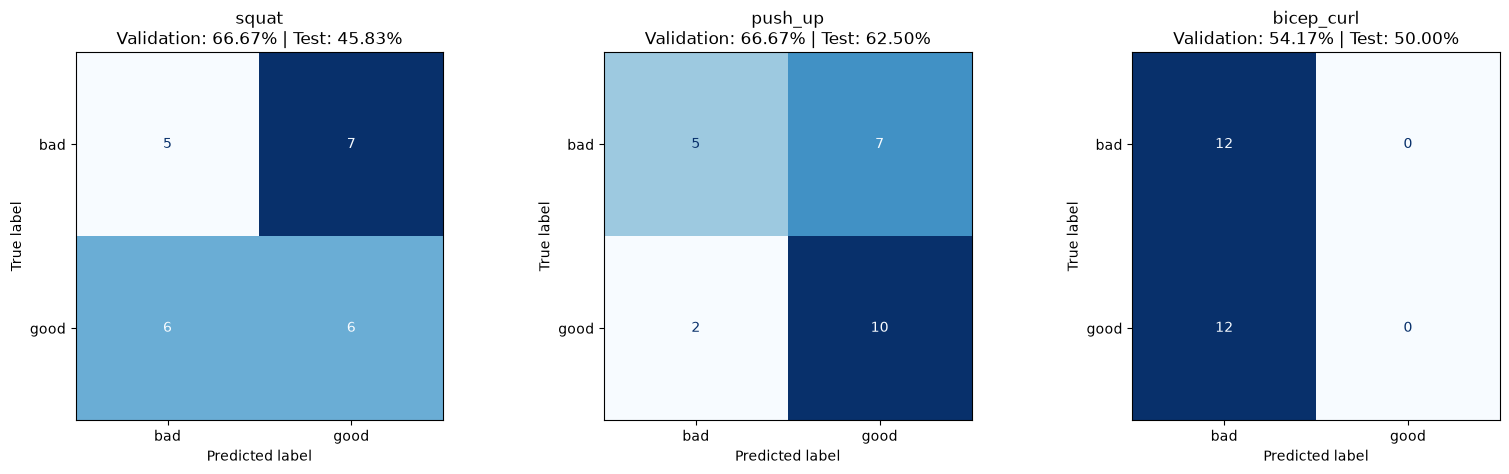


FINAL RESULTS
  exercise  validation_accuracy  test_accuracy  pca_components    C
     squat             0.666667       0.458333              10 0.01
   push_up             0.666667       0.625000              10 3.00
bicep_curl             0.541667       0.500000               5 0.03

Overall video quality accuracy: 52.78%

Combined classification report:
              precision    recall  f1-score   support

         bad     0.5238    0.6111    0.5641        36
        good     0.5333    0.4444    0.4848        36

    accuracy                         0.5278        72
   macro avg     0.5286    0.5278    0.5245        72
weighted avg     0.5286    0.5278    0.5245        72


Models saved in: C:\GymProject\models\quality_embedding_v1
Results saved in: C:\GymProject\prepared\quality_embedding_v1


In [12]:
from pathlib import Path
%pip install tqdm
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm
from ultralytics import YOLO

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================================================
# 1. المسارات
# =========================================================

DATA_ROOT = Path(
    r"C:\GymProject\prepared\exercise_quality_v1"
)

YOLO_MODEL = Path(
    r"C:\GymProject\runs\exercise_quality_20260921_194251\weights\best.pt"
)

OUTPUT_DIR = Path(
    r"C:\GymProject\prepared\quality_embedding_v1"
)

MODEL_DIR = Path(
    r"C:\GymProject\models\quality_embedding_v1"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT}"
assert YOLO_MODEL.exists(), f"Model not found: {YOLO_MODEL}"

print("Dataset:", DATA_ROOT)
print("YOLO model:", YOLO_MODEL)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


# =========================================================
# 2. معرفة اسم الفيديو من اسم الصورة
# =========================================================

def remove_frame_suffix(image_stem):
    """
    يحذف رقم/رمز اللقطة من نهاية اسم الصورة ويعيد اسم الفيديو.
    يدعم عدة صيغ محتملة لأسماء الصور.
    """

    patterns = [
        r"(?i)(?:__|_)(?:frame|img|image)[_-]?\d+$",
        r"(?i)(?:__|_)f[_-]?\d+$",
        r"(?i)__\d+$",
        r"(?i)_\d{3,8}$"
    ]

    result = image_stem

    for pattern in patterns:
        new_result = re.sub(pattern, "", result)

        if new_result != result:
            return new_result

    return result


# =========================================================
# 3. إنشاء جدول الصور
# =========================================================

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for split in ["train", "val", "test"]:
    split_dir = DATA_ROOT / split

    if not split_dir.exists():
        continue

    for class_dir in split_dir.iterdir():

        if not class_dir.is_dir():
            continue

        class_name = class_dir.name

        if class_name.endswith("_good"):
            exercise = class_name[:-5]
            quality = "good"

        elif class_name.endswith("_bad"):
            exercise = class_name[:-4]
            quality = "bad"

        else:
            print("Skipped unknown class:", class_name)
            continue

        for image_path in sorted(class_dir.iterdir()):

            if image_path.suffix.lower() not in image_extensions:
                continue

            video = remove_frame_suffix(image_path.stem)

            subject_match = re.search(
                r"subject[_-]?(\d+)",
                video,
                flags=re.IGNORECASE
            )

            subject = (
                subject_match.group(1).zfill(3)
                if subject_match
                else "unknown"
            )

            records.append({
                "image_path": str(image_path),
                "image_name": image_path.name,
                "video": video,
                "subject": subject,
                "split": split,
                "exercise": exercise,
                "quality": quality,
                "class_name": class_name
            })

images_df = pd.DataFrame(records)

print("\nImages:", len(images_df))
print("Videos:", images_df["video"].nunique())

print("\nVideos per split:")
print(
    images_df.groupby("split")["video"]
    .nunique()
    .reindex(["train", "val", "test"])
)

frames_per_video = (
    images_df.groupby(
        ["split", "exercise", "quality", "video"]
    )
    .size()
)

print("\nFrames per video:")
print(frames_per_video.describe())

if images_df["video"].nunique() != 444:
    print("\nFirst image names:")
    print(images_df[["image_name", "video"]].head(20).to_string(index=False))

    raise ValueError(
        f"Expected 444 videos, but found "
        f"{images_df['video'].nunique()}. "
        "The frame suffix parser needs adjustment."
    )

if len(images_df) != 5328:
    raise ValueError(
        f"Expected 5328 images, but found {len(images_df)}"
    )


# =========================================================
# 4. تحميل YOLO واستخراج Embeddings
# =========================================================

model = YOLO(str(YOLO_MODEL))

video_rows = []
video_features = []

group_columns = [
    "split",
    "exercise",
    "quality",
    "video",
    "subject"
]

video_groups = list(
    images_df.groupby(group_columns, sort=True)
)

for group_number, (group_key, group) in enumerate(
    tqdm(video_groups, desc="Extracting video embeddings"),
    start=1
):
    split, exercise, quality, video, subject = group_key

    # ترتيب اللقطات زمنيًا حسب اسم الملف
    group = group.sort_values("image_name")
    image_paths = group["image_path"].tolist()

    embedding_output = model.embed(
        source=image_paths,
        imgsz=320,
        device=0 if torch.cuda.is_available() else "cpu",
        verbose=False
    )

    embeddings = []

    for item in embedding_output:

        if isinstance(item, torch.Tensor):
            array = item.detach().float().cpu().numpy()
        else:
            array = np.asarray(item)

        if array.ndim == 1:
            embeddings.append(array)

        elif array.ndim == 2:
            embeddings.extend(list(array))

        else:
            array = array.reshape(array.shape[0], -1)
            embeddings.extend(list(array))

    embeddings = np.asarray(embeddings, dtype=np.float32)

    if len(embeddings) != len(image_paths):
        raise ValueError(
            f"{video}: expected {len(image_paths)} embeddings, "
            f"received {len(embeddings)}"
        )

    # إحصائيات تمثل الفيديو كاملًا
    mean_features = embeddings.mean(axis=0)
    std_features = embeddings.std(axis=0)
    percentile_10 = np.percentile(embeddings, 10, axis=0)
    percentile_90 = np.percentile(embeddings, 90, axis=0)

    if len(embeddings) > 1:
        temporal_change = np.abs(
            np.diff(embeddings, axis=0)
        ).mean(axis=0)
    else:
        temporal_change = np.zeros_like(mean_features)

    combined_features = np.concatenate([
        mean_features,
        std_features,
        percentile_10,
        percentile_90,
        temporal_change
    ]).astype(np.float32)

    video_features.append(combined_features)

    video_rows.append({
        "split": split,
        "exercise": exercise,
        "quality": quality,
        "target": 1 if quality == "good" else 0,
        "video": video,
        "subject": subject,
        "sampled_frames": len(image_paths)
    })

video_df = pd.DataFrame(video_rows)
X = np.stack(video_features)

print("\nVideo feature matrix:", X.shape)
print("\nVideos per category:")
print(
    video_df.groupby(
        ["split", "exercise", "quality"]
    ).size().unstack(fill_value=0)
)

np.save(OUTPUT_DIR / "video_embeddings.npy", X)
video_df.to_csv(
    OUTPUT_DIR / "video_metadata.csv",
    index=False
)

print("\nSaved embeddings:", OUTPUT_DIR)


# =========================================================
# 5. تدريب نموذج جودة مستقل لكل تمرين
# =========================================================

exercise_results = []
test_predictions = []

pca_options = [5, 10, 15, 20, 30]
c_options = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]

exercises = ["squat", "push_up", "bicep_curl"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8)
)

for axis, exercise in zip(axes, exercises):

    exercise_mask = video_df["exercise"].eq(exercise)

    train_indices = video_df.index[
        exercise_mask & video_df["split"].eq("train")
    ].to_numpy()

    val_indices = video_df.index[
        exercise_mask & video_df["split"].eq("val")
    ].to_numpy()

    test_indices = video_df.index[
        exercise_mask & video_df["split"].eq("test")
    ].to_numpy()

    X_train = X[train_indices]
    y_train = video_df.loc[
        train_indices, "target"
    ].to_numpy()

    X_val = X[val_indices]
    y_val = video_df.loc[
        val_indices, "target"
    ].to_numpy()

    X_test = X[test_indices]
    y_test = video_df.loc[
        test_indices, "target"
    ].to_numpy()

    best_model = None
    best_val_accuracy = -1
    best_parameters = None

    maximum_components = min(
        len(X_train) - 1,
        X_train.shape[1]
    )

    for components in pca_options:

        if components > maximum_components:
            continue

        for c_value in c_options:

            candidate = Pipeline([
                ("scaler", StandardScaler()),
                (
                    "pca",
                    PCA(
                        n_components=components,
                        random_state=42
                    )
                ),
                (
                    "classifier",
                    LogisticRegression(
                        C=c_value,
                        class_weight="balanced",
                        max_iter=5000,
                        random_state=42
                    )
                )
            ])

            candidate.fit(X_train, y_train)

            val_prediction = candidate.predict(X_val)
            val_accuracy = accuracy_score(
                y_val,
                val_prediction
            )

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_model = candidate
                best_parameters = {
                    "pca_components": components,
                    "C": c_value
                }

    test_prediction = best_model.predict(X_test)
    test_probability = best_model.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    exercise_results.append({
        "exercise": exercise,
        "validation_accuracy": best_val_accuracy,
        "test_accuracy": test_accuracy,
        **best_parameters
    })

    exercise_test_metadata = video_df.loc[
        test_indices
    ].copy()

    exercise_test_metadata["true_target"] = y_test
    exercise_test_metadata["predicted_target"] = test_prediction
    exercise_test_metadata["good_probability"] = test_probability
    exercise_test_metadata["predicted_quality"] = np.where(
        test_prediction == 1,
        "good",
        "bad"
    )

    test_predictions.append(exercise_test_metadata)

    joblib.dump(
        best_model,
        MODEL_DIR / f"{exercise}_quality_embedding.joblib"
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_prediction,
        display_labels=["bad", "good"],
        cmap="Blues",
        colorbar=False,
        ax=axis
    )

    axis.set_title(
        f"{exercise}\n"
        f"Validation: {best_val_accuracy:.2%} | "
        f"Test: {test_accuracy:.2%}"
    )

    print("\n" + "=" * 60)
    print(exercise)
    print("Best parameters:", best_parameters)
    print(f"Validation accuracy: {best_val_accuracy:.2%}")
    print(f"Test accuracy: {test_accuracy:.2%}")

    print(
        classification_report(
            y_test,
            test_prediction,
            target_names=["bad", "good"],
            digits=4,
            zero_division=0
        )
    )

plt.tight_layout()
plt.show()


# =========================================================
# 6. النتيجة الإجمالية
# =========================================================

results_df = pd.DataFrame(exercise_results)

all_test_predictions = pd.concat(
    test_predictions,
    ignore_index=True
)

overall_accuracy = accuracy_score(
    all_test_predictions["true_target"],
    all_test_predictions["predicted_target"]
)

results_df.to_csv(
    OUTPUT_DIR / "quality_results.csv",
    index=False
)

all_test_predictions.to_csv(
    OUTPUT_DIR / "test_video_predictions.csv",
    index=False
)

with open(
    OUTPUT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "overall_test_accuracy": float(overall_accuracy),
            "models": exercise_results
        },
        file,
        indent=2
    )

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(results_df.to_string(index=False))

print(
    f"\nOverall video quality accuracy: "
    f"{overall_accuracy:.2%}"
)

print("\nCombined classification report:")

print(
    classification_report(
        all_test_predictions["true_target"],
        all_test_predictions["predicted_target"],
        target_names=["bad", "good"],
        digits=4,
        zero_division=0
    )
)

print("\nModels saved in:", MODEL_DIR)
print("Results saved in:", OUTPUT_DIR)